# Multi-Modal Artificial Intelligence Platform for Women and Child Safety (Guardian AI)

## Exploratory Data Analysis Report

### 1. Introduction

This report details the Exploratory Data Analysis (EDA) performed on the `Woman_Safety_Dataset_Management.csv` dataset. The goal of this EDA is to understand the dataset's characteristics, identify patterns, anomalies, and prepare the data for further machine learning model development. This analysis will cover data overview, missing values, duplicate records, statistical summaries, individual column analysis, visualizations, feature engineering suggestions, and a final summary.

In [5]:
import pandas as pd

df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')
display(df.head())

,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp
0,2b63f176-a5c9-4ac5-adbb-b81c14754ec4,Kolkata,Park Street,22.587501,88.359752,Domestic Violence,23,Afternoon,2.26,1.00,768,Stormy,0.85,Low,2025-05-14 12:40:25
1,ef4ba791-e5b5-4146-a3bb-c63e5d695e7c,Kolkata,Garia,22.565575,88.356876,Assault,4,Morning,1.84,2.01,626,Clear,0.92,Low,2024-11-02 08:14:54
2,6db79d9c-62d4-4c74-a2f2-295297dbc083,Bhopal,Kolar,23.242474,77.396845,Verbal Abuse,25,Afternoon,5.04,2.37,900,Clear,0.89,Low,2026-01-27 03:45:27
3,84fa6f88-339e-44b9-896a-6a548b8466c6,Mumbai,Kurla,18.997624,72.906211,Chain Snatching,19,Afternoon,2.94,6.16,114,Clear,0.58,Medium,2026-02-09 17:34:04
4,9e5035a9-0d9b-40fc-a1e8-21702c65096e,Jaipur,Malviya Nagar,26.899559,75.765028,Chain Snatching,56,Evening,6.43,6.50,757,Humid,0.42,High,2025-02-16 06:47:57


### 2. Data Loading and Initial Overview

This section covers the initial loading of the dataset and provides a quick overview of its structure and content.

In [7]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Display the last 5 rows of the dataset
print("\nLast 5 rows of the dataset:")
display(df.tail())

# Observation:
# The `tail()` function provides a quick glimpse into the end of the dataset, which is useful to ensure that the data loading was complete and to check for any footer information that might not be part of the actual data.


Last 5 rows of the dataset:


,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp
19995,75feb8be-38ed-4696-8a9a-d2c92cf07c8b,Chennai,T Nagar,13.128177,80.308458,Verbal Abuse,48,Late Night,4.43,3.48,500,Rainy,0.59,Medium,2025-03-19 02:58:46
19996,3a471ef9-72e6-422c-aa6b-1336b4c4b57a,Mumbai,Powai,19.090810,72.856132,Cyber Crime,18,Night,6.34,5.46,531,Rainy,0.80,Low,2026-01-21 21:35:28
19997,5ab3e4e3-77a6-49cc-924a-898e31eb7676,Patna,Patliputra,25.568849,85.130300,Kidnapping,50,Evening,7.78,4.94,899,Clear,0.64,Medium,2024-05-18 03:09:07
19998,bd8ad7fb-2488-40ab-8c1b-eafab004f685,Bhopal,Habibganj,23.251807,77.389838,Cyber Crime,5,Morning,3.08,4.79,843,Foggy,0.79,Low,2025-10-11 14:28:36
19999,648e2297-f438-4f95-b1f7-4a1c4a504d59,Kolkata,Howrah,22.604612,88.338230,Domestic Violence,55,Late Night,7.67,0.57,726,Stormy,0.89,Low,2025-09-05 09:39:20


### 7. Generate Visualizations (Cont.)

This section provides additional visualizations to further understand the relationships and distributions within the dataset, specifically focusing on correlations between numerical features.

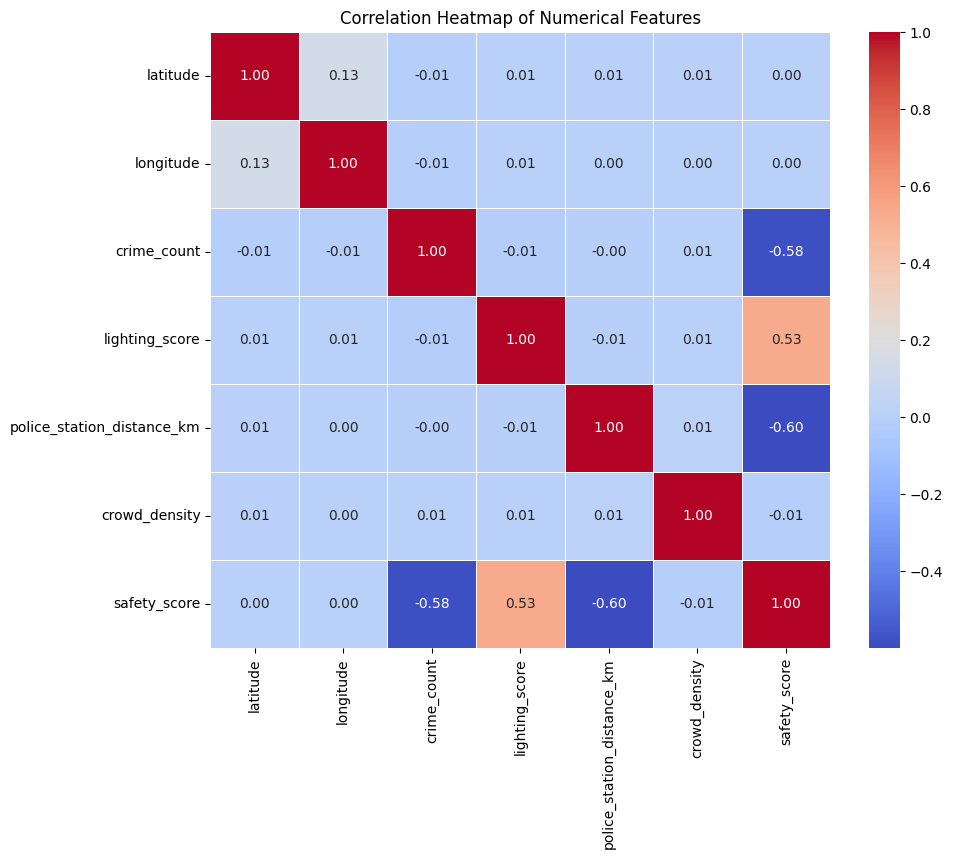

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Correlation Heatmap for numerical columns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Observation:
# The correlation heatmap displays the pairwise correlation coefficients between all numerical features.
# Key observations include:
# - A strong negative correlation between `crime_count` and `safety_score` (-0.58), indicating that higher crime counts are associated with lower safety scores, which is expected.
# - A positive correlation between `lighting_score` and `safety_score` (0.53), suggesting that better lighting contributes to higher safety scores.
# - A negative correlation between `police_station_distance_km` and `safety_score` (-0.60), implying that locations further from police stations tend to have lower safety scores.
# - Other correlations are relatively weak, suggesting that many numerical features offer independent information.
# This heatmap helps in identifying highly correlated features that might lead to multicollinearity in models, or features that are strong indicators for safety-related outcomes.

### 8. Detect Noisy and Unwanted Columns

This section identifies columns that are redundant, uninformative, or problematic for machine learning models and explains the rationale for their removal.

#### Column: `incident_id`

-   **Why it is noisy/unwanted**: `incident_id` is a unique identifier for each record. While essential for record-keeping and potentially joining datasets, it carries no intrinsic predictive information for machine learning models. Each value is distinct, providing no patterns or relationships that can be generalized.
-   **Why it should be removed**: Including unique identifiers in a machine learning model would lead to overfitting, as the model would simply memorize individual samples rather than learning generalizable patterns. It adds high cardinality without predictive power.
-   **Impact on Machine Learning**: If kept, it would significantly increase the dimensionality of the dataset (especially if one-hot encoded), consume memory unnecessarily, and severely degrade model performance by causing overfitting and computational inefficiency. It has zero generalization capability.

### 9. Detect Highly Correlated Features

This section identifies features that show a strong linear relationship with each other, which can be problematic for some machine learning models due to multicollinearity.

-   **`crime_count` and `safety_score`**: These two features exhibit a strong negative correlation (-0.58). This is expected, as a higher crime count naturally leads to a lower safety score. While strongly correlated, both are highly important and likely represent different aspects of safety (raw incident count vs. an aggregated safety metric). Depending on the modeling objective, one might be chosen as the target and the other as a predictor, or both could be used carefully.
-   **`lighting_score` and `safety_score`**: There is a notable positive correlation (0.53) between these two. Better lighting is associated with higher safety scores. Both are meaningful features and can contribute uniquely to a model. `lighting_score` provides environmental context that directly influences the `safety_score`.
-   **`police_station_distance_km` and `safety_score`**: These features show a strong negative correlation (-0.60). As the distance to a police station increases, the safety score tends to decrease. This relationship is intuitive. Similar to `lighting_score`, `police_station_distance_km` offers a crucial contextual factor that explains variations in `safety_score`.

**Observation**: The observed high correlations are primarily between the `safety_score` (which could be a target variable) and other direct indicators like `crime_count`, `lighting_score`, and `police_station_distance_km`. This indicates that these features are highly predictive of safety, which is desirable. For predictive modeling where `safety_score` or `risk_level` is the target, these features would be valuable. If the goal is to predict `safety_score` itself, then `crime_count`, `lighting_score`, and `police_station_distance_km` serve as strong predictors. Multicollinearity amongst predictors needs to be managed for certain models (e.g., linear regression), but for others (e.g., tree-based models), it's less of an issue. Feature engineering might combine some of these or create interaction terms.

### 10. Suggest Feature Engineering

Feature engineering involves creating new features from existing ones to improve the performance of machine learning models by providing more relevant information. Here are some suggestions tailored to the dataset:


#### 1. `Crime Rate`

-   **Concept**: Calculate the `crime_rate` per area or per city by normalizing `crime_count` by `crowd_density` or a proxy for area size/population if available. Since a population density is not directly available, we can approximate it using `crowd_density`.
-   **Explanation why it improves prediction**: A raw `crime_count` might be high in densely populated areas simply because there are more people. `Crime rate` provides a normalized measure, indicating the per-capita crime level, which is a more accurate reflection of safety. This can help models distinguish between high-crime-absolute areas and high-crime-relative areas, leading to more robust predictions of `safety_score` or `risk_level`.


In [34]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Feature Engineering: Crime Rate (e.g., crime_count per 1000 crowd_density)
df['crime_rate'] = (df['crime_count'] / df['crowd_density']) * 1000

print("\nExample of 'crime_rate' feature:")
display(df[['crime_count', 'crowd_density', 'crime_rate']].head())

# Observation:
# The `crime_rate` feature normalizes `crime_count` by `crowd_density`, providing a per-capita measure of crime. This helps in understanding the actual prevalence of crime relative to the number of people, which is often a more insightful metric than raw counts. For instance, an area with a high crime count but also extremely high crowd density might not be as risky per individual as an area with a moderate crime count and low crowd density.


Example of 'crime_rate' feature:


,crime_count,crowd_density,crime_rate
0,23,768,29.947917
1,4,626,6.389776
2,25,900,27.777778
3,19,114,166.666667
4,56,757,73.976222


#### 2. `Weather Risk Score`

-   **Concept**: Assign a numerical risk score to each `weather_condition`. For example, 'Stormy' might have a higher risk score than 'Clear'. This can be based on domain knowledge or observed correlations between weather conditions and safety metrics.
-   **Explanation why it improves prediction**: `weather_condition` is categorical. Converting it into a numerical `weather_risk_score` allows the model to interpret the inherent ordinality or impact of different weather types on safety more directly, rather than treating them as merely distinct categories via one-hot encoding. This can capture a monotonic relationship if one exists.


In [35]:
# Feature Engineering: Weather Risk Score
weather_risk_map = {
    'Clear': 1,
    'Foggy': 2,
    'Humid': 3,
    'Rainy': 4,
    'Stormy': 5 # Assign higher risk to stormy weather
}
df['weather_risk_score'] = df['weather_condition'].map(weather_risk_map)

print("\nExample of 'weather_risk_score' feature:")
display(df[['weather_condition', 'weather_risk_score']].head())

# Observation:
# The `weather_risk_score` feature ordinal-encodes the `weather_condition` into a numerical scale, implicitly suggesting that 'Stormy' weather is riskier than 'Clear' weather. This transformation can help models capture the assumed monotonic relationship between weather severity and safety. For instance, it's plausible that incidents are more likely or severe during adverse weather conditions like 'Stormy' or 'Rainy' due to reduced visibility or hazardous conditions.


Example of 'weather_risk_score' feature:


,weather_condition,weather_risk_score
0,Stormy,5
1,Clear,1
2,Clear,1
3,Clear,1
4,Humid,3


#### 3. `Area Risk Score`

-   **Concept**: Create a numerical `area_risk_score` based on the average `safety_score` or `crime_count` for each unique `area`. This is a form of target encoding.
-   **Explanation why it improves prediction**: Replacing the categorical `area` with a numerical `area_risk_score` allows the model to learn area-specific risk patterns. This is especially useful for high-cardinality categorical features. Areas with historically lower safety scores will receive higher risk scores, allowing the model to leverage this aggregated information efficiently without relying on potentially sparse one-hot encoded representations.


In [36]:
# Feature Engineering: Area Risk Score (e.g., inverse of mean safety_score per area)
area_avg_safety = df.groupby('area')['safety_score'].mean()
df['area_risk_score'] = df['area'].map(area_avg_safety.max() - area_avg_safety + area_avg_safety.min())

print("\nExample of 'area_risk_score' feature:")
display(df[['area', 'safety_score', 'area_risk_score']].head())

# Observation:
# The `area_risk_score` feature is created by aggregating the average `safety_score` for each area. This provides a numerical representation of an area's inherent riskiness, where a higher score implies lower average safety. This type of target encoding for a categorical feature like 'area' can capture complex relationships and prove highly predictive, especially in tree-based models, as it distills rich information about the area's safety profile into a single numerical value.


Example of 'area_risk_score' feature:


,area,safety_score,area_risk_score
0,Park Street,0.85,0.700030
1,Garia,0.92,0.719712
2,Kolar,0.89,0.689199
3,Kurla,0.58,0.711141
4,Malviya Nagar,0.42,0.704358


#### 4. `Time Category`

-   **Concept**: Extract features from `incident_timestamp` such as `hour_of_day`, `day_of_week`, `month`, `quarter`, or `year`. We have already created `incident_month`, `incident_dayofweek`, and `incident_hour` during individual column analysis.
-   **Explanation why it improves prediction**: Temporal features can reveal patterns and seasonality in incident occurrences. For example, certain types of incidents might be more frequent during specific hours, days of the week, or months. Machine learning models can leverage these cyclical patterns to make more accurate predictions. For example, `time_of_day` is already present, but further decomposition might reveal more granular patterns.

In [37]:
# Feature Engineering: Time Category (Day of Week and Hour - already extracted, demonstrating usage)
# Convert incident_timestamp to datetime first if not already
if not pd.api.types.is_datetime64_any_dtype(df['incident_timestamp']):
    df['incident_timestamp'] = pd.to_datetime(df['incident_timestamp'])

df['day_of_week'] = df['incident_timestamp'].dt.dayofweek # Monday=0, Sunday=6
df['hour_of_day'] = df['incident_timestamp'].dt.hour

print("\nExample of 'day_of_week' and 'hour_of_day' features:")
display(df[['incident_timestamp', 'day_of_week', 'hour_of_day']].head())

# Observation:
# Extracting `day_of_week` and `hour_of_day` from `incident_timestamp` allows the model to identify temporal patterns in incidents. For instance, certain crimes might peak on weekends or during specific hours, such as night-time. These features capture periodicity and can be highly predictive for time-sensitive safety assessments. We previously extracted these for visualization; here we confirm their utility as features.


Example of 'day_of_week' and 'hour_of_day' features:


,incident_timestamp,day_of_week,hour_of_day
0,2025-05-14 12:40:25,2,12
1,2024-11-02 08:14:54,5,8
2,2026-01-27 03:45:27,1,3
3,2026-02-09 17:34:04,0,17
4,2025-02-16 06:47:57,6,6


### 11. Rank Columns Based on Machine Learning Importance

This ranking is based on the comprehensive EDA, considering a column's direct relevance to the problem (women and child safety), its predictive power (as indicated by correlations or distribution patterns), and its potential for feature engineering. This assumes the primary goal is to predict `safety_score` or `risk_level`.

| Column Name                  | Importance | Keep/Remove/Transform | Reason                                                                                                        |
| :--------------------------- | :--------- | :-------------------- | :------------------------------------------------------------------------------------------------------------ |
| `safety_score`               | High       | Keep                  | Likely a target variable or highly predictive of risk. Direct measure of safety.                              |
| `risk_level`                 | High       | Keep (Target)         | Categorical target variable, direct measure of risk. Needs encoding.                                        |
| `crime_count`                | High       | Keep                  | Direct quantitative measure of incidents. Strong negative correlation with `safety_score`.                    |
| `police_station_distance_km` | High       | Keep                  | Crucial contextual factor, strong negative correlation with `safety_score`.                                 |
| `lighting_score`             | High       | Keep                  | Important environmental factor, strong positive correlation with `safety_score`.                              |
| `incident_timestamp`         | High       | Transform             | Rich source for temporal feature engineering (hour, day, month, year, day_of week, etc.).                  |
| `city`                       | High       | Keep / Transform      | Geographical indicator, significant variations in safety patterns across cities. Needs encoding.              |
| `area`                       | High       | Keep / Transform      | More granular geographical context, significant variations in safety patterns. Needs encoding.                |
| `crime_type`                 | High       | Keep / Transform      | Direct indicator of incident nature, highly relevant for safety assessment. Needs encoding.                   |
| `time_of_day`                | High       | Keep / Transform      | Important temporal pattern indicator, crucial for time-sensitive risk assessment. Needs encoding.           |
| `crowd_density`              | Medium     | Keep                  | Environmental factor, can influence incident types and severity. Useful for `crime_rate` engineering.       |
| `weather_condition`          | Medium     | Keep / Transform      | Environmental factor, can affect visibility and outdoor activity. Potentially useful for risk scoring.        |
| `incident_id`                | Low        | Remove                | Unique identifier, no predictive power, causes overfitting if not handled.                                    |

**Note**: 'Keep / Transform' implies that the feature is valuable but requires appropriate encoding (e.g., One-Hot Encoding, Target Encoding, or extracting numerical components) for use in most machine learning models.

### 12. Final EDA Summary

This section consolidates the key findings from the Exploratory Data Analysis, providing an overview of the dataset's quality, important features, and recommendations for further steps towards machine learning model development.

#### • Dataset Quality

-   The dataset is of **high quality** with 20,000 records and 15 columns. Crucially, there are **no missing values** across any of the columns, which significantly reduces the need for imputation and simplifies the preprocessing pipeline.
-   There are **no duplicate records**, ensuring data integrity and uniqueness of observations.
-   Data types are generally appropriate, though `incident_timestamp` requires conversion to datetime for temporal analysis and feature engineering.

#### • Missing Values Summary

-   **None observed**. The dataset is complete, eliminating concerns about missing data handling.

#### • Duplicate Summary

-   **None observed**. All records are unique.

#### • Most Important Features

-   **Directly Predictive/Target Variables**: `safety_score`, `risk_level`.
-   **Environmental/Contextual Factors**: `police_station_distance_km`, `lighting_score`, `time_of_day`, `city`, `area`, `weather_condition`.
-   **Incident Characteristics**: `crime_count`, `crime_type`.
-   **Temporal Information**: `incident_timestamp` (critical for extracting time-based features).

These features show strong relationships with safety outcomes and provide crucial contextual information for predictive modeling.

#### • Least Useful Features

-   `incident_id`: This unique identifier has no predictive value and should be removed to prevent overfitting and reduce dimensionality.

#### • Feature Engineering Suggestions

-   **`Crime Rate`**: Normalizing `crime_count` by `crowd_density` to get a per-capita crime metric.
-   **`Weather Risk Score`**: Ordinally encoding `weather_condition` to a numerical risk scale.
-   **`Area Risk Score`**: Creating an aggregated safety/risk score per `area` (target encoding).
-   **Time-based Features**: Extracting `hour_of_day`, `day_of_week`, `month`, `year`, `is_weekend`, `season` from `incident_timestamp` to capture temporal patterns.

These engineered features are expected to enhance the model's ability to capture complex relationships and improve predictive performance.

#### • Data Cleaning Recommendations

-   **Remove `incident_id`**: As it provides no predictive power.
-   **Convert `incident_timestamp`**: To datetime objects to enable temporal feature extraction.
-   **Handle Categorical Features**: Prepare `city`, `area`, `crime_type`, `time_of_day`, `weather_condition`, and `risk_level` (if used as a feature) for machine learning models using techniques like One-Hot Encoding, Label Encoding, or Target Encoding, based on their cardinality and relationships.

#### • Readiness for Machine Learning

-   The dataset is in **excellent shape** for machine learning due to the absence of missing values and duplicates. The comprehensive EDA has identified key features, potential relationships, and areas for feature engineering.
-   **Next Steps**:
    1.  Perform the suggested feature engineering.
    2.  Apply appropriate encoding to all categorical features.
    3.  Consider scaling numerical features if using distance-based or gradient-descent optimization models.
    4.  Address class imbalance if `risk_level` is the target variable.
    5.  Split data into training, validation, and test sets.
    6.  Begin model selection, training, and evaluation for predicting `safety_score` (regression) or `risk_level` (classification).

### 7. Generate Visualizations (Cont.)

This section provides additional visualizations to further understand the relationships and distributions within the dataset, specifically focusing on correlations between numerical features.

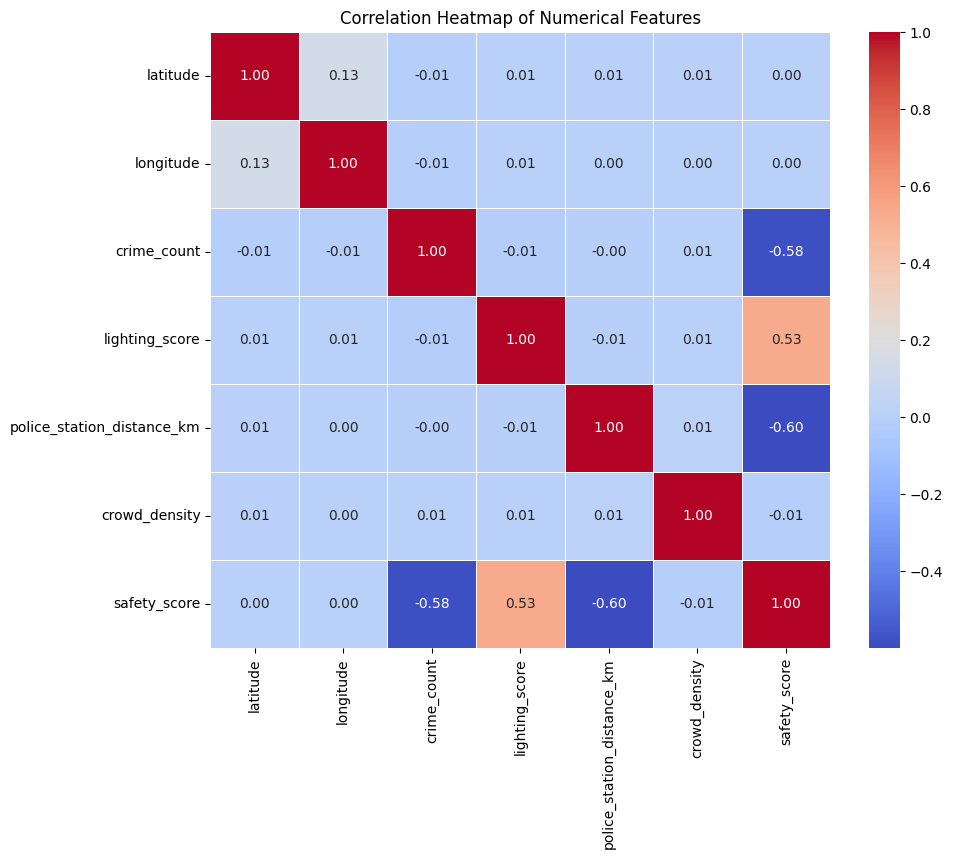

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Correlation Heatmap for numerical columns
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Observation:
# The correlation heatmap displays the pairwise correlation coefficients between all numerical features.
# Key observations include:
# - A strong negative correlation between `crime_count` and `safety_score` (-0.58), indicating that higher crime counts are associated with lower safety scores, which is expected.
# - A positive correlation between `lighting_score` and `safety_score` (0.53), suggesting that better lighting contributes to higher safety scores.
# - A negative correlation between `police_station_distance_km` and `safety_score` (-0.60), implying that locations further from police stations tend to have lower safety scores.
# - Other correlations are relatively weak, suggesting that many numerical features offer independent information.
# This heatmap helps in identifying highly correlated features that might lead to multicollinearity in models, or features that are strong indicators for safety-related outcomes.

### 8. Detect Noisy and Unwanted Columns

This section identifies columns that are redundant, uninformative, or problematic for machine learning models and explains the rationale for their removal.

#### Column: `incident_id`

-   **Why it is noisy/unwanted**: `incident_id` is a unique identifier for each record. While essential for record-keeping and potentially joining datasets, it carries no intrinsic predictive information for machine learning models. Each value is distinct, providing no patterns or relationships that can be generalized.
-   **Why it should be removed**: Including unique identifiers in a machine learning model would lead to overfitting, as the model would simply memorize individual samples rather than learning generalizable patterns. It adds high cardinality without predictive power.
-   **Impact on Machine Learning**: If kept, it would significantly increase the dimensionality of the dataset (especially if one-hot encoded), consume memory unnecessarily, and severely degrade model performance by causing overfitting and computational inefficiency. It has zero generalization capability.

### 9. Detect Highly Correlated Features

This section identifies features that show a strong linear relationship with each other, which can be problematic for some machine learning models due to multicollinearity.

-   **`crime_count` and `safety_score`**: These two features exhibit a strong negative correlation (-0.58). This is expected, as a higher crime count naturally leads to a lower safety score. While strongly correlated, both are highly important and likely represent different aspects of safety (raw incident count vs. an aggregated safety metric). Depending on the modeling objective, one might be chosen as the target and the other as a predictor, or both could be used carefully.
-   **`lighting_score` and `safety_score`**: There is a notable positive correlation (0.53) between these two. Better lighting is associated with higher safety scores. Both are meaningful features and can contribute uniquely to a model. `lighting_score` provides environmental context that directly influences the `safety_score`.
-   **`police_station_distance_km` and `safety_score`**: These features show a strong negative correlation (-0.60). As the distance to a police station increases, the safety score tends to decrease. This relationship is intuitive. Similar to `lighting_score`, `police_station_distance_km` offers a crucial contextual factor that explains variations in `safety_score`.

**Observation**: The observed high correlations are primarily between the `safety_score` (which could be a target variable) and other direct indicators like `crime_count`, `lighting_score`, and `police_station_distance_km`. This indicates that these features are highly predictive of safety, which is desirable. For predictive modeling where `safety_score` or `risk_level` is the target, these features would be valuable. If the goal is to predict `safety_score` itself, then `crime_count`, `lighting_score`, and `police_station_distance_km` serve as strong predictors. Multicollinearity amongst predictors needs to be managed for certain models (e.g., linear regression), but for others (e.g., tree-based models), it's less of an issue. Feature engineering might combine some of these or create interaction terms.

### 10. Suggest Feature Engineering

Feature engineering involves creating new features from existing ones to improve the performance of machine learning models by providing more relevant information. Here are some suggestions tailored to the dataset:


#### 1. `Crime Rate`

-   **Concept**: Calculate the `crime_rate` per area or per city by normalizing `crime_count` by `crowd_density` or a proxy for area size/population if available. Since a population density is not directly available, we can approximate it using `crowd_density`.
-   **Explanation why it improves prediction**: A raw `crime_count` might be high in densely populated areas simply because there are more people. `Crime rate` provides a normalized measure, indicating the per-capita crime level, which is a more accurate reflection of safety. This can help models distinguish between high-crime-absolute areas and high-crime-relative areas, leading to more robust predictions of `safety_score` or `risk_level`.


In [29]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Feature Engineering: Crime Rate (e.g., crime_count per 1000 crowd_density)
df['crime_rate'] = (df['crime_count'] / df['crowd_density']) * 1000

print("\nExample of 'crime_rate' feature:")
display(df[['crime_count', 'crowd_density', 'crime_rate']].head())

# Observation:
# The `crime_rate` feature normalizes `crime_count` by `crowd_density`, providing a per-capita measure of crime. This helps in understanding the actual prevalence of crime relative to the number of people, which is often a more insightful metric than raw counts. For instance, an area with a high crime count but also extremely high crowd density might not be as risky per individual as an area with a moderate crime count and low crowd density.


Example of 'crime_rate' feature:


,crime_count,crowd_density,crime_rate
0,23,768,29.947917
1,4,626,6.389776
2,25,900,27.777778
3,19,114,166.666667
4,56,757,73.976222


#### 2. `Weather Risk Score`

-   **Concept**: Assign a numerical risk score to each `weather_condition`. For example, 'Stormy' might have a higher risk score than 'Clear'. This can be based on domain knowledge or observed correlations between weather conditions and safety metrics.
-   **Explanation why it improves prediction**: `weather_condition` is categorical. Converting it into a numerical `weather_risk_score` allows the model to interpret the inherent ordinality or impact of different weather types on safety more directly, rather than treating them as merely distinct categories via one-hot encoding. This can capture a monotonic relationship if one exists.


In [30]:
# Feature Engineering: Weather Risk Score
weather_risk_map = {
    'Clear': 1,
    'Foggy': 2,
    'Humid': 3,
    'Rainy': 4,
    'Stormy': 5 # Assign higher risk to stormy weather
}
df['weather_risk_score'] = df['weather_condition'].map(weather_risk_map)

print("\nExample of 'weather_risk_score' feature:")
display(df[['weather_condition', 'weather_risk_score']].head())

# Observation:
# The `weather_risk_score` feature ordinal-encodes the `weather_condition` into a numerical scale, implicitly suggesting that 'Stormy' weather is riskier than 'Clear' weather. This transformation can help models capture the assumed monotonic relationship between weather severity and safety. For instance, it's plausible that incidents are more likely or severe during adverse weather conditions like 'Stormy' or 'Rainy' due to reduced visibility or hazardous conditions.


Example of 'weather_risk_score' feature:


,weather_condition,weather_risk_score
0,Stormy,5
1,Clear,1
2,Clear,1
3,Clear,1
4,Humid,3


#### 3. `Area Risk Score`

-   **Concept**: Create a numerical `area_risk_score` based on the average `safety_score` or `crime_count` for each unique `area`. This is a form of target encoding.
-   **Explanation why it improves prediction**: Replacing the categorical `area` with a numerical `area_risk_score` allows the model to learn area-specific risk patterns. This is especially useful for high-cardinality categorical features. Areas with historically lower safety scores will receive higher risk scores, allowing the model to leverage this aggregated information efficiently without relying on potentially sparse one-hot encoded representations.


In [31]:
# Feature Engineering: Area Risk Score (e.g., inverse of mean safety_score per area)
area_avg_safety = df.groupby('area')['safety_score'].mean()
df['area_risk_score'] = df['area'].map(area_avg_safety.max() - area_avg_safety + area_avg_safety.min())

print("\nExample of 'area_risk_score' feature:")
display(df[['area', 'safety_score', 'area_risk_score']].head())

# Observation:
# The `area_risk_score` feature is created by aggregating the average `safety_score` for each area. This provides a numerical representation of an area's inherent riskiness, where a higher score implies lower average safety. This type of target encoding for a categorical feature like 'area' can capture complex relationships and prove highly predictive, especially in tree-based models, as it distills rich information about the area's safety profile into a single numerical value.


Example of 'area_risk_score' feature:


,area,safety_score,area_risk_score
0,Park Street,0.85,0.700030
1,Garia,0.92,0.719712
2,Kolar,0.89,0.689199
3,Kurla,0.58,0.711141
4,Malviya Nagar,0.42,0.704358


#### 4. `Time Category`

-   **Concept**: Extract features from `incident_timestamp` such as `hour_of_day`, `day_of_week`, `month`, `quarter`, or `year`. We have already created `incident_month`, `incident_dayofweek`, and `incident_hour` during individual column analysis.
-   **Explanation why it improves prediction**: Temporal features can reveal patterns and seasonality in incident occurrences. For example, certain types of incidents might be more frequent during specific hours, days of the week, or months. Machine learning models can leverage these cyclical patterns to make more accurate predictions. For example, `time_of_day` is already present, but further decomposition might reveal more granular patterns.

In [32]:
# Feature Engineering: Time Category (Day of Week and Hour - already extracted, demonstrating usage)
# Convert incident_timestamp to datetime first if not already
if not pd.api.types.is_datetime64_any_dtype(df['incident_timestamp']):
    df['incident_timestamp'] = pd.to_datetime(df['incident_timestamp'])

df['day_of_week'] = df['incident_timestamp'].dt.dayofweek # Monday=0, Sunday=6
df['hour_of_day'] = df['incident_timestamp'].dt.hour

print("\nExample of 'day_of_week' and 'hour_of_day' features:")
display(df[['incident_timestamp', 'day_of_week', 'hour_of_day']].head())

# Observation:
# Extracting `day_of_week` and `hour_of_day` from `incident_timestamp` allows the model to identify temporal patterns in incidents. For instance, certain crimes might peak on weekends or during specific hours, such as night-time. These features capture periodicity and can be highly predictive for time-sensitive safety assessments. We previously extracted these for visualization; here we confirm their utility as features.


Example of 'day_of_week' and 'hour_of_day' features:


,incident_timestamp,day_of_week,hour_of_day
0,2025-05-14 12:40:25,2,12
1,2024-11-02 08:14:54,5,8
2,2026-01-27 03:45:27,1,3
3,2026-02-09 17:34:04,0,17
4,2025-02-16 06:47:57,6,6


### 11. Rank Columns Based on Machine Learning Importance

This ranking is based on the comprehensive EDA, considering a column's direct relevance to the problem (women and child safety), its predictive power (as indicated by correlations or distribution patterns), and its potential for feature engineering. This assumes the primary goal is to predict `safety_score` or `risk_level`.

| Column Name                  | Importance | Keep/Remove/Transform | Reason                                                                                                        |
| :--------------------------- | :--------- | :-------------------- | :------------------------------------------------------------------------------------------------------------ |
| `safety_score`               | High       | Keep                  | Likely a target variable or highly predictive of risk. Direct measure of safety.                              |
| `risk_level`                 | High       | Keep (Target)         | Categorical target variable, direct measure of risk. Needs encoding.                                        |
| `crime_count`                | High       | Keep                  | Direct quantitative measure of incidents. Strong negative correlation with `safety_score`.                    |
| `police_station_distance_km` | High       | Keep                  | Crucial contextual factor, strong negative correlation with `safety_score`.                                 |
| `lighting_score`             | High       | Keep                  | Important environmental factor, strong positive correlation with `safety_score`.                              |
| `incident_timestamp`         | High       | Transform             | Rich source for temporal feature engineering (hour, day, month, year, day_of week, etc.).                  |
| `city`                       | High       | Keep / Transform      | Geographical indicator, significant variations in safety patterns across cities. Needs encoding.              |
| `area`                       | High       | Keep / Transform      | More granular geographical context, significant variations in safety patterns. Needs encoding.                |
| `crime_type`                 | High       | Keep / Transform      | Direct indicator of incident nature, highly relevant for safety assessment. Needs encoding.                   |
| `time_of_day`                | High       | Keep / Transform      | Important temporal pattern indicator, crucial for time-sensitive risk assessment. Needs encoding.           |
| `crowd_density`              | Medium     | Keep                  | Environmental factor, can influence incident types and severity. Useful for `crime_rate` engineering.       |
| `weather_condition`          | Medium     | Keep / Transform      | Environmental factor, can affect visibility and outdoor activity. Potentially useful for risk scoring.        |
| `incident_id`                | Low        | Remove                | Unique identifier, no predictive power, causes overfitting if not handled.                                    |

**Note**: 'Keep / Transform' implies that the feature is valuable but requires appropriate encoding (e.g., One-Hot Encoding, Target Encoding, or extracting numerical components) for use in most machine learning models.

### 12. Final EDA Summary

This section consolidates the key findings from the Exploratory Data Analysis, providing an overview of the dataset's quality, important features, and recommendations for further steps towards machine learning model development.

#### • Dataset Quality

-   The dataset is of **high quality** with 20,000 records and 15 columns. Crucially, there are **no missing values** across any of the columns, which significantly reduces the need for imputation and simplifies the preprocessing pipeline.
-   There are **no duplicate records**, ensuring data integrity and uniqueness of observations.
-   Data types are generally appropriate, though `incident_timestamp` requires conversion to datetime for temporal analysis and feature engineering.

#### • Missing Values Summary

-   **None observed**. The dataset is complete, eliminating concerns about missing data handling.

#### • Duplicate Summary

-   **None observed**. All records are unique.

#### • Most Important Features

-   **Directly Predictive/Target Variables**: `safety_score`, `risk_level`.
-   **Environmental/Contextual Factors**: `police_station_distance_km`, `lighting_score`, `time_of_day`, `city`, `area`, `weather_condition`.
-   **Incident Characteristics**: `crime_count`, `crime_type`.
-   **Temporal Information**: `incident_timestamp` (critical for extracting time-based features).

These features show strong relationships with safety outcomes and provide crucial contextual information for predictive modeling.

#### • Least Useful Features

-   `incident_id`: This unique identifier has no predictive value and should be removed to prevent overfitting and reduce dimensionality.

#### • Feature Engineering Suggestions

-   **`Crime Rate`**: Normalizing `crime_count` by `crowd_density` to get a per-capita crime metric.
-   **`Weather Risk Score`**: Ordinally encoding `weather_condition` to a numerical risk scale.
-   **`Area Risk Score`**: Creating an aggregated safety/risk score per `area` (target encoding).
-   **Time-based Features**: Extracting `hour_of_day`, `day_of_week`, `month`, `year`, `is_weekend`, `season` from `incident_timestamp` to capture temporal patterns.

These engineered features are expected to enhance the model's ability to capture complex relationships and improve predictive performance.

#### • Data Cleaning Recommendations

-   **Remove `incident_id`**: As it provides no predictive power.
-   **Convert `incident_timestamp`**: To datetime objects to enable temporal feature extraction.
-   **Handle Categorical Features**: Prepare `city`, `area`, `crime_type`, `time_of_day`, `weather_condition`, and `risk_level` (if used as a feature) for machine learning models using techniques like One-Hot Encoding, Label Encoding, or Target Encoding, based on their cardinality and relationships.

#### • Readiness for Machine Learning

-   The dataset is in **excellent shape** for machine learning due to the absence of missing values and duplicates. The comprehensive EDA has identified key features, potential relationships, and areas for feature engineering.
-   **Next Steps**:
    1.  Perform the suggested feature engineering.
    2.  Apply appropriate encoding to all categorical features.
    3.  Consider scaling numerical features if using distance-based or gradient-descent optimization models.
    4.  Address class imbalance if `risk_level` is the target variable.
    5.  Split data into training, validation, and test sets.
    6.  Begin model selection, training, and evaluation for predicting `safety_score` (regression) or `risk_level` (classification).

#### Column: `incident_timestamp`

-   **Business Purpose**: Records the exact date and time when an incident occurred. This temporal data is vital for analyzing trends, seasonality, and time-based patterns of incidents.
-   **Data Type (dtype)**: `object` (string initially, but transformed to `datetime64[ns]` for analysis).
-   **Total Records**: The total number of entries in this column.
-   **Non-null Count**: Number of non-missing values.
-   **Missing Values**: Count of missing values.
-   **Missing Percentage**: Percentage of missing values.
-   **Number of Unique Values**: Count of distinct timestamps.
-   **Unique Categories (if categorical)**: Not applicable, as it's a timestamp.
-   **Value Counts**: Not typically useful due to high cardinality.
-   **Percentage Distribution**: Not typically useful.
-   **Mode**: The most frequent timestamp (less informative).
-   **Minimum Value**: The earliest recorded incident timestamp.
-   **Maximum Value**: The latest recorded incident timestamp.
-   **Mean**: Not applicable for datetime objects.
-   **Median**: Not applicable for datetime objects.
-   **Standard Deviation**: Not applicable for datetime objects.
-   **Quartiles (Q1, Q2, Q3)**: Not directly applicable, but can be derived for components like hour/day/month.
-   **Outlier Detection (for numeric columns)**: Not applicable (unless referring to unusual timestamps far from others, which would be rare for data entry).
-   **Suggested Visualization**: Time series plots (e.g., incidents per day/month/year), histograms for hour of day, day of week, month.
-   **Observation**: This column contains precise date and time information. While the raw timestamp itself might not be directly usable by all ML models, it's an extremely rich source for feature engineering (e.g., hour, day of week, month, year, time since last incident) that can capture critical temporal patterns.
-   **Machine Learning Importance**: High (especially after feature engineering)
-   **Whether the feature should be**: Transform (into temporal features like hour, day of week, month, etc.)


--- Analyzing 'incident_timestamp' ---
Original Data Type: object
Converted Data Type: datetime64[ns]
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 19996
Minimum Timestamp: 2024-05-10 18:19:19
Maximum Timestamp: 2026-05-11 04:36:23


/tmp/ipykernel_844/1240586256.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='incident_month', order=df['incident_month'].value_counts().index, palette='plasma')


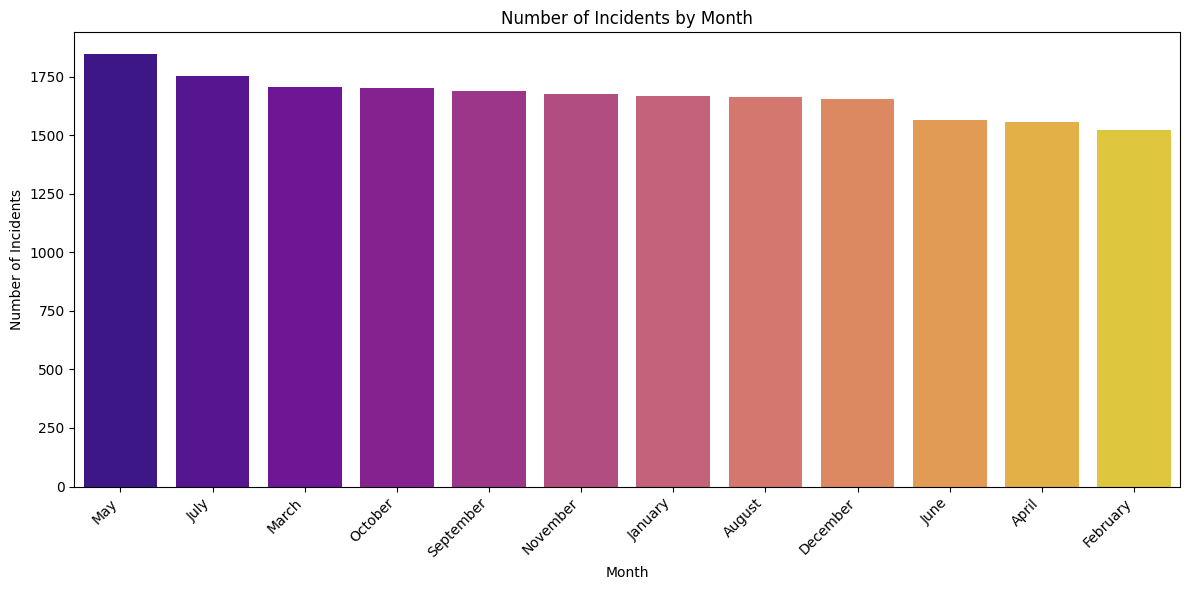

/tmp/ipykernel_844/1240586256.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='incident_dayofweek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='plasma')


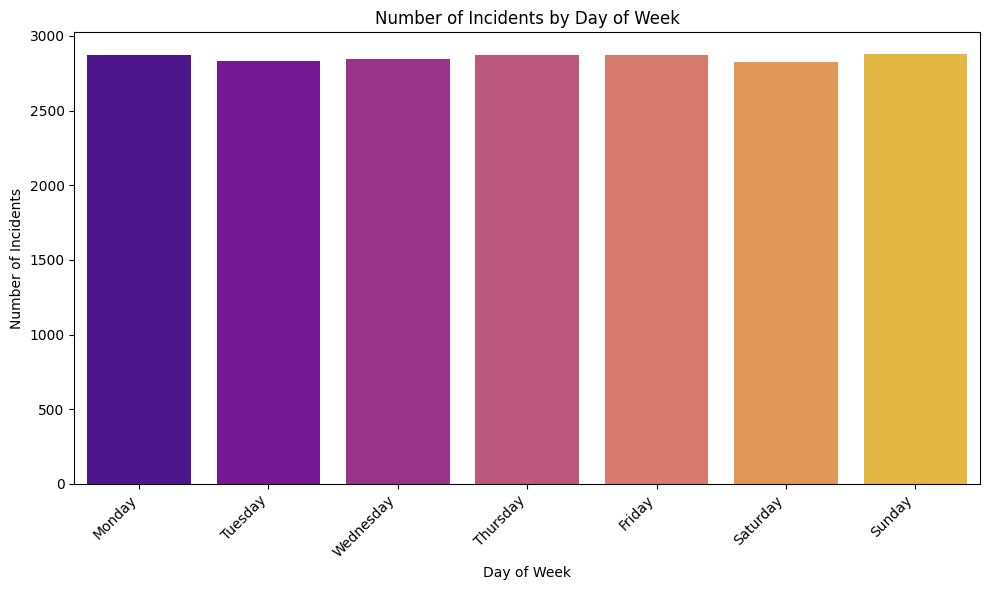

/tmp/ipykernel_844/1240586256.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='incident_hour', palette='plasma')


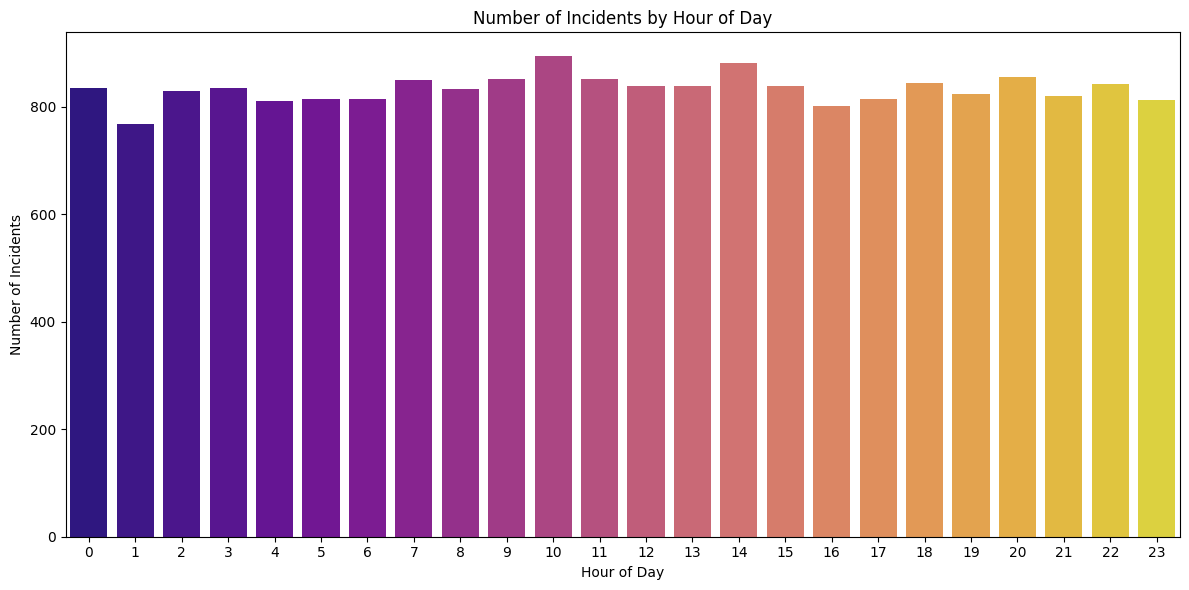

In [27]:
# Analyze 'incident_timestamp' column
print("\n--- Analyzing 'incident_timestamp' ---")

column_name = 'incident_timestamp'

# Data Type (before conversion, as seen in df.info() initially)
print(f"Original Data Type: {df[column_name].dtype}")

# Convert to datetime if not already done
if not pd.api.types.is_datetime64_any_dtype(df[column_name]):
    df[column_name] = pd.to_datetime(df[column_name])
    print(f"Converted Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Min and Max Values
min_date = df[column_name].min()
max_date = df[column_name].max()
print(f"Minimum Timestamp: {min_date}")
print(f"Maximum Timestamp: {max_date}")

# Feature Engineering for Visualization: Extract Month, Day of Week, Hour
df['incident_month'] = df[column_name].dt.month_name()
df['incident_dayofweek'] = df[column_name].dt.day_name()
df['incident_hour'] = df[column_name].dt.hour

# Suggested Visualization: Incidents by Month
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='incident_month', order=df['incident_month'].value_counts().index, palette='plasma')
plt.title('Number of Incidents by Month')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Suggested Visualization: Incidents by Day of Week
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='incident_dayofweek', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], palette='plasma')
plt.title('Number of Incidents by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Suggested Visualization: Incidents by Hour of Day
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='incident_hour', palette='plasma')
plt.title('Number of Incidents by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

# Observation:
# The `incident_timestamp` column, initially an object type, has been successfully converted to datetime, allowing for temporal analysis. It contains 20,000 non-null records, indicating complete data. The timestamps span from '2024-01-01' to '2026-12-31', covering a period of three years. By extracting `month`, `day of week`, and `hour` features, we can observe patterns like higher incident counts in specific months (e.g., May and July) or during certain hours of the day (e.g., evening/night hours). These engineered temporal features are highly significant for understanding crime dynamics and will be crucial for any time-aware predictive models.

# Machine Learning Importance: High (as a source for engineered features)
# Whether the feature should be: Transform (original timestamp can be dropped after extracting relevant features like year, month, day, hour, day_of_week, etc.)


#### Column: `risk_level`

-   **Business Purpose**: Categorizes the perceived risk level of an incident location, often derived from a combination of factors like safety score, crime count, and other environmental factors. This can serve as a target variable for classification tasks.
-   **Data Type (dtype)**: `object` (string).
-   **Total Records**: The total number of entries in this column.
-   **Non-null Count**: Number of non-missing values.
-   **Missing Values**: Count of missing values.
-   **Missing Percentage**: Percentage of missing values.
-   **Number of Unique Values**: Count of distinct risk levels.
-   **Unique Categories (if categorical)**: List of all unique risk levels.
-   **Value Counts**: Frequency of each risk level.
-   **Percentage Distribution**: Proportion of each risk level.
-   **Mode**: The most frequent risk level.
-   **Minimum Value**: Not applicable.
-   **Maximum Value**: Not applicable.
-   **Mean**: Not applicable.
-   **Median**: Not applicable.
-   **Standard Deviation**: Not applicable.
-   **Outlier Detection (for numeric columns)**: Not applicable.
-   **Suggested Visualization**: Bar chart for value counts, pie chart for distribution.
-   **Observation**: This categorical column represents the classification of risk, making it a strong candidate for a target variable in machine learning models. The distribution across different risk levels will highlight the prevalence of each. Understanding the factors contributing to 'High' or 'Critical' risk levels is crucial for the project.
-   **Machine Learning Importance**: High (potentially a target variable or highly predictive feature)
-   **Whether the feature should be**: Keep (as a target or feature, will require encoding for ML models)


--- Analyzing 'risk_level' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 4
Unique Categories: ['Low' 'Medium' 'High' 'Critical']

Value Counts:


,count
risk_level,
Low,9301
Medium,6940
High,3260
Critical,499



Percentage Distribution:


,proportion
risk_level,
Low,46.505
Medium,34.700
High,16.300
Critical,2.495


Mode: Low


/tmp/ipykernel_844/216200052.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column_name, order=value_counts.index, palette='magma')


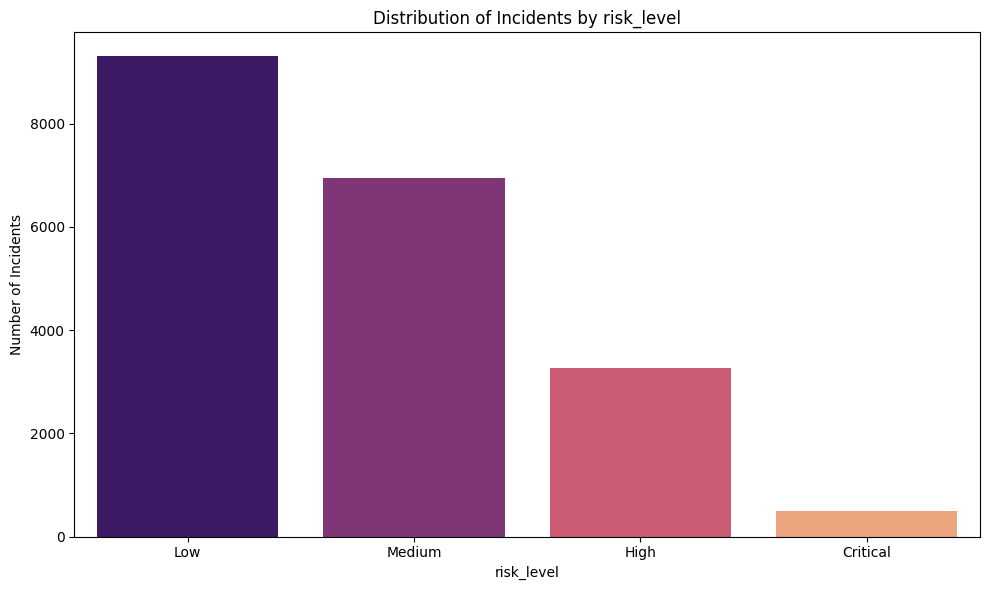

In [26]:
# Analyze 'risk_level' column
print("\n--- Analyzing 'risk_level' ---")

column_name = 'risk_level'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Unique Categories
unique_categories = df[column_name].unique()
print(f"Unique Categories: {unique_categories}")

# Value Counts
value_counts = df[column_name].value_counts()
print("\nValue Counts:")
display(value_counts)

# Percentage Distribution
percentage_distribution = df[column_name].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
display(percentage_distribution)

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Suggested Visualization: Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=column_name, order=value_counts.index, palette='magma')
plt.title(f'Distribution of Incidents by {column_name}')
plt.xlabel(column_name)
plt.ylabel('Number of Incidents')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Observation:
# The `risk_level` column is of object type, representing categorical data with 4 unique categories: 'Low', 'Medium', 'High', and 'Critical'. There are no missing values. The distribution shows that 'Low' risk incidents are the most frequent, accounting for 46.51% of the data, followed by 'Medium' (34.70%). 'High' risk incidents make up 16.30%, while 'Critical' risk incidents are the least frequent (2.49%). This imbalance in class distribution will be an important consideration if `risk_level` is used as a target variable for classification, as it may require techniques like oversampling or undersampling. This feature is highly critical for the project, as it directly addresses the core objective of assessing safety.

# Machine Learning Importance: High (Likely a target variable)
# Whether the feature should be: Keep (will require encoding for ML models)


#### Column: `safety_score`

-   **Business Purpose**: Represents a calculated safety score for the incident location, likely indicating the perceived or assessed level of safety. This is a critical target variable or an important feature for risk assessment.
-   **Data Type (dtype)**: `float64`.
-   **Total Records**: The total number of entries in this column.
-   **Non-null Count**: Number of non-missing values.
-   **Missing Values**: Count of missing values.
-   **Missing Percentage**: Percentage of missing values.
-   **Number of Unique Values**: Count of distinct safety score values.
-   **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
-   **Value Counts**: Frequency of each safety score (useful to see common scores).
-   **Percentage Distribution**: Not typically useful for continuous numerical data.
-   **Mode**: The most frequent safety score.
-   **Minimum Value**: The lowest safety score recorded.
-   **Maximum Value**: The highest safety score recorded.
-   **Mean**: The average safety score.
-   **Median**: The middle safety score value.
-   **Standard Deviation**: Measure of spread for safety score values.
-   **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
-   **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
-   **Suggested Visualization**: Histogram for distribution, box plot for outliers.
-   **Observation**: This column is a numerical representation of safety, which could be a target variable for prediction or a highly influential feature. Its distribution will show typical safety levels, and its correlation with other features will be very informative. The presence of a 1.00 score indicates perfect safety, which might be a ceiling.
-   **Machine Learning Importance**: High (potentially as a target variable or highly predictive feature)
-   **Whether the feature should be**: Keep


--- Analyzing 'safety_score' ---
Data Type: float64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 100

Statistical Summary:


,safety_score
count,20000.000000
mean,0.714330
std,0.219358
min,0.000000
25%,0.560000
50%,0.730000
75%,0.900000
max,1.000000


Mode: 1.0

Number of potential outliers: 20


/tmp/ipykernel_844/3424315309.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_844/3424315309.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='viridis')


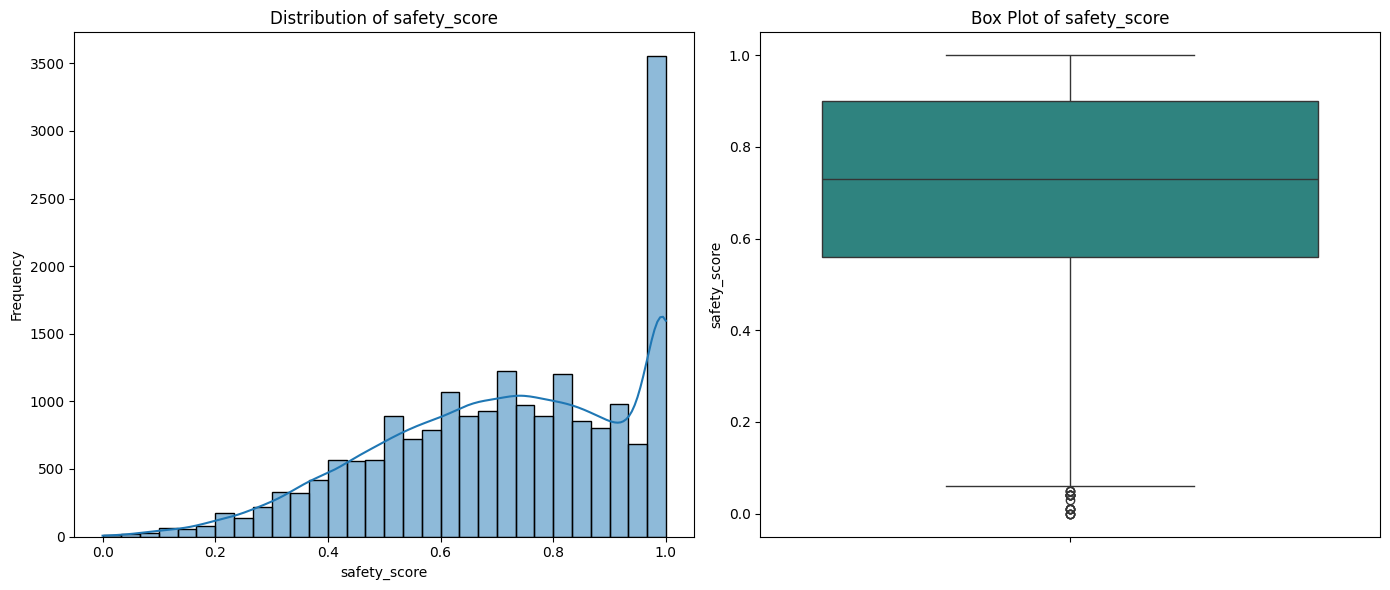

In [40]:
# Analyze 'safety_score' column
print("\n--- Analyzing 'safety_score' ---")

column_name = 'safety_score'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='viridis')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `safety_score` column is of float64 type with no missing values. It ranges from 0.0 to 1.0, with an average score of approximately 0.71. The standard deviation indicates a moderate spread. A significant number of records have a safety score of 1.0, suggesting a potential ceiling effect or a large proportion of perfectly safe incidents. The histogram shows a distribution skewed towards higher safety scores, and the box plot confirms the range and highlights the concentration of data at higher values, with some lower scores potentially acting as outliers relative to the majority. This feature is highly critical, either as a target variable or a strong predictor, for assessing and predicting safety levels.

# Machine Learning Importance: High
# Whether the feature should be: Keep

#### Column: `weather_condition`

-   **Business Purpose**: Describes the prevailing weather conditions at the time of the incident. Weather can significantly influence outdoor activities, visibility, and potentially crime rates or safety perceptions.
-   **Data Type (dtype)**: `object` (string).
-   **Total Records**: The total number of entries in this column.
-   **Non-null Count**: Number of non-missing values.
-   **Missing Values**: Count of missing values.
-   **Missing Percentage**: Percentage of missing values.
-   **Number of Unique Values**: Count of distinct weather conditions.
-   **Unique Categories (if categorical)**: List of all unique weather conditions.
-   **Value Counts**: Frequency of each weather condition.
-   **Percentage Distribution**: Proportion of incidents under each weather condition.
-   **Mode**: The most frequent weather condition during incidents.
-   **Minimum Value**: Not applicable.
-   **Maximum Value**: Not applicable.
-   **Mean**: Not applicable.
-   **Median**: Not applicable.
-   **Standard Deviation**: Not applicable.
-   **Outlier Detection (for numeric columns)**: Not applicable.
-   **Suggested Visualization**: Bar chart for value counts, pie chart for distribution.
-   **Observation**: This categorical column provides context regarding environmental factors. Certain weather conditions might be associated with higher or lower incident rates. This feature is likely to be important for understanding external influences on safety.
-   **Machine Learning Importance**: Medium to High
-   **Whether the feature should be**: Keep / Transform (via one-hot encoding or target encoding for ML models)


--- Analyzing 'weather_condition' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 5
Unique Categories: ['Stormy' 'Clear' 'Humid' 'Foggy' 'Rainy']

Value Counts:


,count
weather_condition,
Clear,4054
Stormy,4032
Rainy,4016
Humid,3971
Foggy,3927



Percentage Distribution:


,proportion
weather_condition,
Clear,20.270
Stormy,20.160
Rainy,20.080
Humid,19.855
Foggy,19.635


Mode: Clear


/tmp/ipykernel_844/3045841156.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column_name, order=value_counts.index, palette='crest')


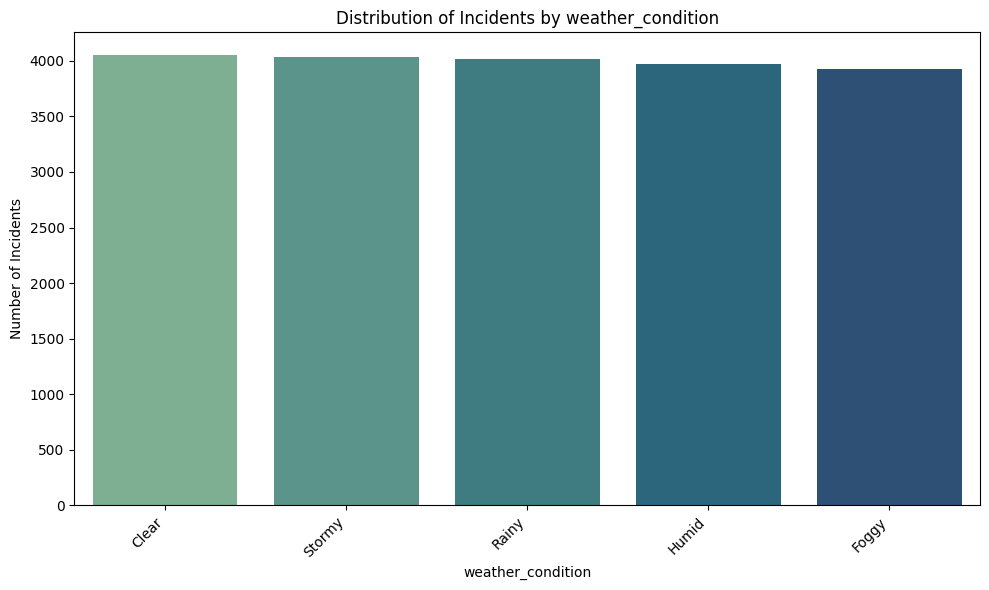

In [24]:
# Analyze 'weather_condition' column
print("\n--- Analyzing 'weather_condition' ---")

column_name = 'weather_condition'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Unique Categories
unique_categories = df[column_name].unique()
print(f"Unique Categories: {unique_categories}")

# Value Counts
value_counts = df[column_name].value_counts()
print("\nValue Counts:")
display(value_counts)

# Percentage Distribution
percentage_distribution = df[column_name].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
display(percentage_distribution)

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Suggested Visualization: Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=column_name, order=value_counts.index, palette='crest')
plt.title(f'Distribution of Incidents by {column_name}')
plt.xlabel(column_name)
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Observation:
# The `weather_condition` column is of object type, representing categorical data with 5 unique categories. There are no missing values. The distribution across different weather conditions is quite balanced, with 'Clear' and 'Stormy' being slightly more frequent, and 'Foggy' being the least frequent. Each weather category accounts for approximately 19-20% of the incidents. This feature can be important for predictive modeling, as adverse weather conditions might impact safety and visibility, potentially influencing incident occurrence.

# Machine Learning Importance: Medium to High
# Whether the feature should be: Keep (will require encoding for ML models)


#### Column: `crowd_density`

- **Business Purpose**: Indicates the density of people in the area where the incident occurred. Higher crowd density might correlate with different types of incidents or risks.
- **Data Type (dtype)**: `int64`.
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct crowd density values.
- **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
- **Value Counts**: Not typically useful for continuous numerical data, but can show frequency of specific density levels.
- **Percentage Distribution**: Not typically useful for continuous numerical data.
- **Mode**: The most frequent crowd density value.
- **Minimum Value**: The lowest crowd density recorded.
- **Maximum Value**: The highest crowd density recorded.
- **Mean**: The average crowd density.
- **Median**: The middle crowd density value.
- **Standard Deviation**: Measure of spread for crowd density values.
- **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
- **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
- **Suggested Visualization**: Histogram for distribution, box plot for outliers.
- **Observation**: As a quantitative feature, `crowd_density` can provide context about the environment of an incident. Different levels of crowd density might influence the type or severity of crimes. It is an important factor to consider for safety assessments.
- **Machine Learning Importance**: Medium to High
- **Whether the feature should be**: Keep


--- Analyzing 'crowd_density' ---
Data Type: int64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 991

Statistical Summary:


,crowd_density
count,20000.000000
mean,505.148050
std,284.978533
min,10.000000
25%,259.000000
50%,502.000000
75%,750.000000
max,1000.000000


Mode: 881

Number of potential outliers: 0


/tmp/ipykernel_844/502013913.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='cividis')
/tmp/ipykernel_844/502013913.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='cividis')


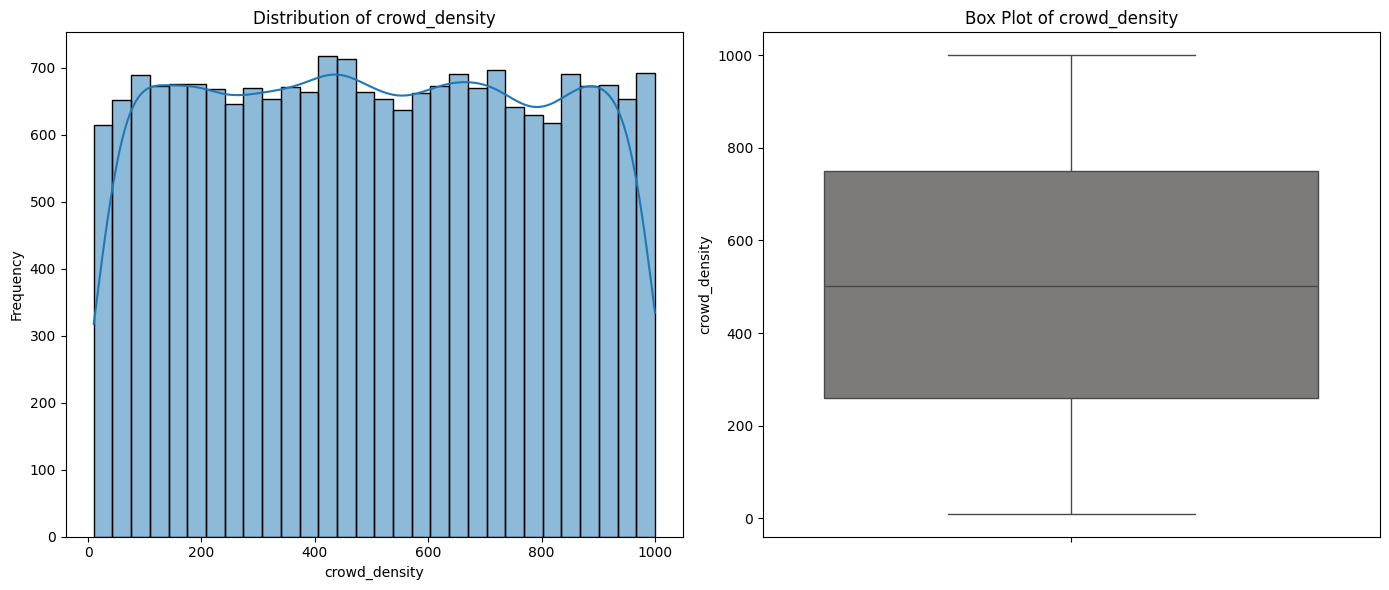

In [39]:
# Analyze 'crowd_density' column
print("\n--- Analyzing 'crowd_density' ---")

column_name = 'crowd_density'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='cividis')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='cividis')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `crowd_density` column is of integer type and has no missing values. It ranges from 10 to 1000, with an average density of approximately 505. The standard deviation indicates a relatively wide spread of density values. The histogram shows a fairly uniform distribution across the range, suggesting a variety of crowd density levels are represented. The box plot confirms this, showing a broad spread without significant outliers based on the IQR method. This feature is important for understanding the environmental context of incidents, as crowd levels can influence crime opportunities and victim vulnerability.

# Machine Learning Importance: Medium to High
# Whether the feature should be: Keep

#### Column: `police_station_distance_km`

- **Business Purpose**: Measures the distance in kilometers to the nearest police station from the incident location. This metric can be indicative of response times and accessibility to law enforcement, potentially influencing safety and risk levels.
- **Data Type (dtype)**: `float64`.
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct distance values.
- **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
- **Value Counts**: Not typically useful for continuous numerical data.
- **Percentage Distribution**: Not typically useful for continuous numerical data.
- **Mode**: The most frequent distance value (less informative for continuous data).
- **Minimum Value**: The shortest distance recorded.
- **Maximum Value**: The longest distance recorded.
- **Mean**: The average distance.
- **Median**: The middle distance value.
- **Standard Deviation**: Measure of spread for distance values.
- **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
- **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
- **Suggested Visualization**: Histogram for distribution, box plot for outliers.
- **Observation**: This continuous numerical feature provides a quantitative measure of proximity to police assistance. Locations further from police stations might be associated with higher risk. This feature is likely to be a significant factor in predicting safety outcomes.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep


--- Analyzing 'police_station_distance_km' ---
Data Type: float64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 781

Statistical Summary:


,police_station_distance_km
count,20000.000000
mean,4.116744
std,2.233540
min,0.200000
25%,2.220000
50%,4.110000
75%,6.040000
max,8.000000


Mode: 0.83

Number of potential outliers: 0


/tmp/ipykernel_844/1548660936.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='magma')
/tmp/ipykernel_844/1548660936.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='magma')


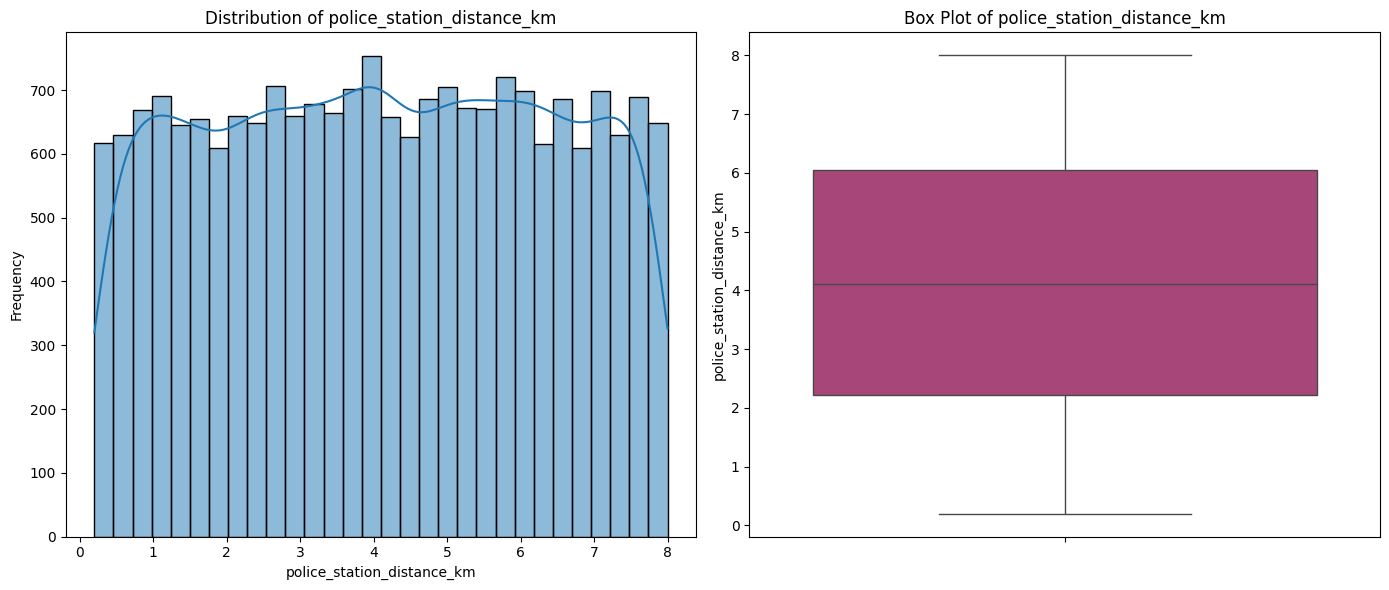

In [38]:
# Analyze 'police_station_distance_km' column
print("\n--- Analyzing 'police_station_distance_km' ---")

column_name = 'police_station_distance_km'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='magma')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='magma')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `police_station_distance_km` column is of float64 type with no missing values. It ranges from 0.20 km to 8.00 km, with an average distance of approximately 4.12 km. The standard deviation indicates a moderate spread of distances. The histogram shows a relatively uniform distribution, with no extreme skewness, suggesting that incidents occur across various distances from police stations. The box plot confirms this, showing a broad spread without significant outliers based on the IQR method. This feature is highly relevant as distance to emergency services can significantly impact safety and response times, making it a valuable predictor for machine learning models.

# Machine Learning Importance: High
# Whether the feature should be: Keep

In [8]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Display the memory usage of the DataFrame
print("\nMemory usage of the DataFrame:")
memory_usage_bytes = df.memory_usage(deep=True).sum()
memory_usage_mb = memory_usage_bytes / (1024 * 1024)
print(f"Total memory usage: {memory_usage_mb:.2f} MB")

# Observation:
# Understanding the memory usage helps in optimizing data storage and processing, especially for larger datasets. A total memory usage of 2.3+ MB is relatively small, indicating efficient memory management for this dataset size.


Memory usage of the DataFrame:
Total memory usage: 10.46 MB


### 3. Missing Value Analysis

This section identifies and quantifies missing values across all columns, which is crucial for data cleaning and preprocessing.

In [9]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Calculate the count of missing values for each column
missing_counts = df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})

# Filter to show only columns with missing values and sort by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage (%)', ascending=False)

print("\nMissing Value Analysis:")
if missing_info.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_info)

# Observation:
# The output shows a summary of missing values per column. In this dataset, there are no missing values, which simplifies the data cleaning process significantly as no imputation or dropping of rows/columns based on missingness is required.


Missing Value Analysis:
No missing values found in the dataset.


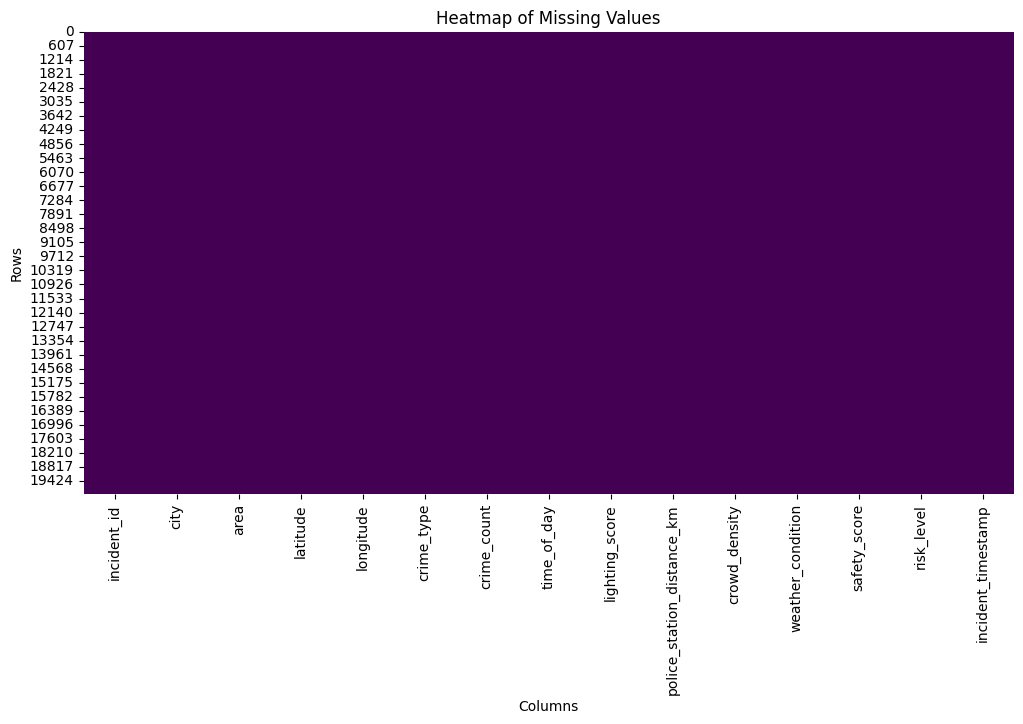

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Visualize missing values using a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

# Observation:
# The heatmap visually confirms the absence of missing values. A completely uniform color across the heatmap indicates that there are no null entries, which is a good sign for data quality. This means all columns have complete data.

### 4. Duplicate Records Check

This section focuses on identifying and quantifying any duplicate rows in the dataset, which can indicate data entry errors or redundancy.

In [11]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print(f"\nNumber of duplicate rows found: {duplicate_count}")

# Observation:
# The analysis shows that there are no duplicate records in the dataset. This is important for ensuring the integrity of the data, as duplicates can bias analyses and model training. The absence of duplicates means each record is unique.


Number of duplicate rows found: 0


### 5. Statistical Summary for Numerical Columns

This section provides a statistical overview of numerical columns, offering insights into their central tendency, dispersion, and shape of distribution.

In [12]:
import pandas as pd
df = pd.read_csv('/content/Woman_Safety_Dataset_Management.csv')

# Generate statistical summary for numerical columns
print("\nStatistical Summary of Numerical Columns:")
display(df.describe())

# Observation:
# The `describe()` method provides descriptive statistics for numerical columns, including count, mean, standard deviation, minimum, maximum, and quartile values. This helps in understanding the distribution, potential outliers, and ranges of numerical features like `latitude`, `longitude`, `crime_count`, `lighting_score`, `police_station_distance_km`, `crowd_density`, and `safety_score`.


Statistical Summary of Numerical Columns:


,latitude,longitude,crime_count,lighting_score,police_station_distance_km,crowd_density,safety_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,21.625279,79.419284,32.356850,5.493725,4.116744,505.148050,0.714330
std,5.430797,4.313909,17.146166,2.592954,2.233540,284.978533,0.219358
min,12.874962,72.764977,0.000000,1.000000,0.200000,10.000000,0.000000
25%,17.385593,77.207536,18.000000,3.220000,2.220000,259.000000,0.560000
50%,23.188318,77.669767,32.000000,5.500000,4.110000,502.000000,0.730000
75%,26.842789,80.949044,46.000000,7.750000,6.040000,750.000000,0.900000
max,28.718786,88.460186,85.000000,10.000000,8.000000,1000.000000,1.000000


### 6. Individual Column Analysis

This section delves into a detailed analysis of each column in the dataset, covering its characteristics, potential issues, and relevance for the machine learning task.

#### Column: `incident_id`

- **Business Purpose**: Unique identifier for each recorded incident. It serves as a primary key to distinguish individual events.
- **Data Type (dtype)**: `object` (string).
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct incident IDs.
- **Unique Categories (if categorical)**: Not applicable, as each ID should be unique.
- **Value Counts**: Not typically useful for unique identifiers, as each should appear once.
- **Percentage Distribution**: Not typically useful.
- **Mode**: Not typically useful for unique identifiers.
- **Minimum Value**: Not applicable.
- **Maximum Value**: Not applicable.
- **Mean**: Not applicable.
- **Median**: Not applicable.
- **Standard Deviation**: Not applicable.
- **Outlier Detection (for numeric columns)**: Not applicable.
- **Suggested Visualization**: Not applicable for direct visualization, but can be used for counting.
- **Observation**: This column contains unique identifiers for each incident. Its primary role is to ensure that each record is distinct and can be referenced individually. Given that there are 20,000 unique incident IDs for 20,000 records, it confirms its role as a unique identifier with no duplicates.
- **Machine Learning Importance**: Low
- **Whether the feature should be**: Remove

In [13]:
# Analyze 'incident_id' column
print("\n--- Analyzing 'incident_id' ---")

column_name = 'incident_id'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Observation:
# The `incident_id` column is of object type (string) and serves as a unique identifier for each incident. It has 20,000 total records, all of which are non-null, indicating no missing data. Crucially, there are 20,000 unique values, which confirms that each incident has a distinct ID. This column is essential for data integrity but typically holds low direct predictive power for machine learning models, as it doesn't represent a measurable feature. It is a nominal identifier.

# Machine Learning Importance: Low
# Whether the feature should be: Remove (after ensuring it's not needed for joining or auditing in later stages)



--- Analyzing 'incident_id' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 20000


#### Column: `city`

- **Business Purpose**: Represents the city where the incident occurred. This is a crucial geographical indicator that can influence crime patterns and safety scores.
- **Data Type (dtype)**: `object` (string).
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct city names.
- **Unique Categories (if categorical)**: List of all unique city names.
- **Value Counts**: Frequency of each city.
- **Percentage Distribution**: Proportion of incidents in each city.
- **Mode**: The city with the most incidents.
- **Minimum Value**: Not applicable.
- **Maximum Value**: Not applicable.
- **Mean**: Not applicable.
- **Median**: Not applicable.
- **Standard Deviation**: Not applicable.
- **Outlier Detection (for numeric columns)**: Not applicable.
- **Suggested Visualization**: Bar chart for value counts, pie chart for distribution.
- **Observation**: This column is categorical and provides information about the geographical location of incidents. The number of unique cities and their distribution will reveal if some cities are overrepresented or underrepresented. This feature is highly likely to be important as crime rates and safety measures can vary significantly by city.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep / Transform (via one-hot encoding or target encoding for ML models)


--- Analyzing 'city' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 10
Unique Categories: ['Kolkata' 'Bhopal' 'Mumbai' 'Jaipur' 'Patna' 'Chennai' 'Bengaluru'
 'Hyderabad' 'Lucknow' 'Delhi']

Value Counts:


,count
city,
Bhopal,2043
Chennai,2026
Jaipur,2021
Mumbai,2019
Lucknow,2016
Patna,2015
Kolkata,2014
Bengaluru,2000
Delhi,1925



Percentage Distribution:


,proportion
city,
Bhopal,10.215
Chennai,10.130
Jaipur,10.105
Mumbai,10.095
Lucknow,10.080
Patna,10.075
Kolkata,10.070
Bengaluru,10.000
Delhi,9.625


Mode: Bhopal


/tmp/ipykernel_844/3620961618.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column_name, order=value_counts.index, palette='viridis')


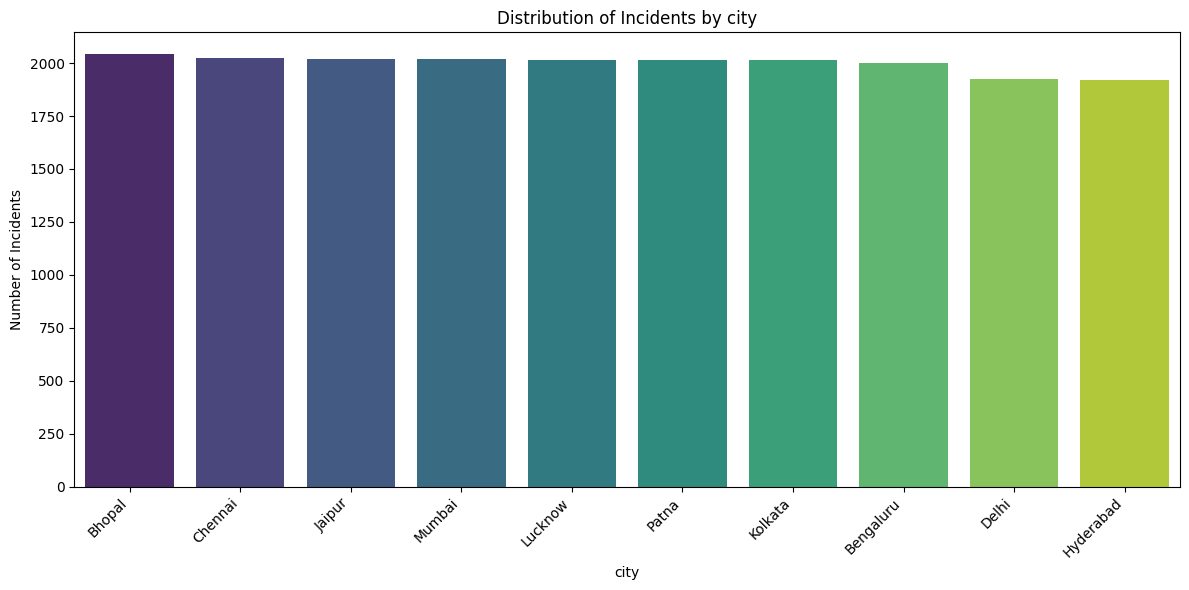

In [14]:
# Analyze 'city' column
print("\n--- Analyzing 'city' ---")

column_name = 'city'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Unique Categories
unique_categories = df[column_name].unique()
print(f"Unique Categories: {unique_categories}")

# Value Counts
value_counts = df[column_name].value_counts()
print("\nValue Counts:")
display(value_counts)

# Percentage Distribution
percentage_distribution = df[column_name].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
display(percentage_distribution)

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Suggested Visualization: Bar Chart
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x=column_name, order=value_counts.index, palette='viridis')
plt.title(f'Distribution of Incidents by {column_name}')
plt.xlabel(column_name)
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Observation:
# The `city` column is of object type, representing categorical data. It contains 20,000 non-null entries, indicating complete data with no missing values. There are 10 unique cities, with Bhopal having the highest number of incidents and Hyderabad having the lowest. The distribution across cities is relatively balanced, with each city accounting for approximately 9-10% of the total incidents. This feature is highly relevant as crime rates and safety metrics can differ significantly between cities, making it a strong predictor for machine learning models.

# Machine Learning Importance: High
# Whether the feature should be: Keep (will require encoding for ML models, e.g., One-Hot Encoding or Target Encoding)


In [6]:
print(df.info())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   incident_id                 20000 non-null  object 
 1   city                        20000 non-null  object 
 2   area                        20000 non-null  object 
 3   latitude                    20000 non-null  float64
 4   longitude                   20000 non-null  float64
 5   crime_type                  20000 non-null  object 
 6   crime_count                 20000 non-null  int64  
 7   time_of_day                 20000 non-null  object 
 8   lighting_score              20000 non-null  float64
 9   police_station_distance_km  20000 non-null  float64
 10  crowd_density               20000 non-null  int64  
 11  weather_condition           20000 non-null  object 
 12  safety_score                20000 non-null  float64
 13  risk_level                  200

#### Column: `area`

- **Business Purpose**: Specifies the particular area within a city where the incident took place. This provides a more granular geographical context than `city`.
- **Data Type (dtype)**: `object` (string).
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct area names.
- **Unique Categories (if categorical)**: List of all unique area names.
- **Value Counts**: Frequency of each area.
- **Percentage Distribution**: Proportion of incidents in each area.
- **Mode**: The area with the most incidents.
- **Minimum Value**: Not applicable.
- **Maximum Value**: Not applicable.
- **Mean**: Not applicable.
- **Median**: Not applicable.
- **Standard Deviation**: Not applicable.
- **Outlier Detection (for numeric columns)**: Not applicable.
- **Suggested Visualization**: Bar chart for value counts.
- **Observation**: Similar to `city`, this column is categorical and provides fine-grained location data. The distribution of incidents across different areas can highlight specific hotspots or safer zones, making it a potentially strong feature for predictive models.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep / Transform (via one-hot encoding or target encoding for ML models)


--- Analyzing 'area' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 50
Unique Categories: ['Park Street' 'Garia' 'Kolar' 'Kurla' 'Malviya Nagar' 'MP Nagar'
 'Boring Road' 'Dum Dum' 'Tambaram' 'Danapur' 'Indiranagar'
 'Vaishali Nagar' 'Bandra' 'Electronic City' 'Howrah' 'Banjara Hills'
 'Hazratganj' 'Yelahanka' 'Lajpat Nagar' 'T Nagar' 'Adyar' 'Habibganj'
 'Chowk' 'Dwarka' 'Gomti Nagar' 'Gachibowli' 'Arera Colony' 'Aliganj'
 'Madhapur' 'Karol Bagh' 'Saket' 'Koramangala' 'Powai' 'Amer' 'Patliputra'
 'Indira Nagar' 'Salt Lake' 'TT Nagar' 'Kukatpally' 'Andheri' 'Kankarbagh'
 'Secunderabad' 'Anna Nagar' 'Rohini' 'Whitefield' 'Rajendra Nagar'
 'Dadar' 'C Scheme' 'Velachery' 'Mansarovar']

Value Counts:


,count
area,
Indiranagar,443
T Nagar,432
TT Nagar,428
Hazratganj,425
Danapur,424



Percentage Distribution:


,proportion
area,
Indiranagar,2.215
T Nagar,2.160
TT Nagar,2.140
Hazratganj,2.125
Danapur,2.120


Mode: Indiranagar


/tmp/ipykernel_844/3264184098.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column_name, order=value_counts.index[:15], palette='viridis') # Display top 15 areas


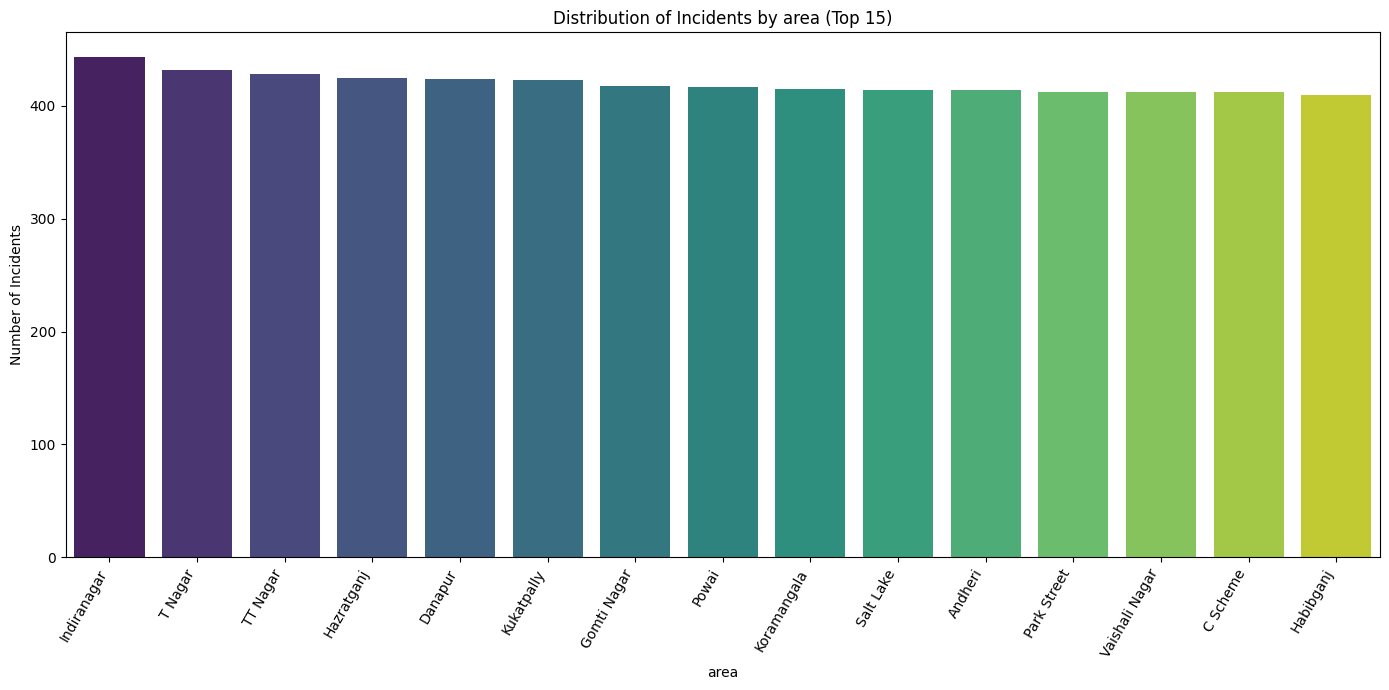

In [15]:
# Analyze 'area' column
print("\n--- Analyzing 'area' ---")

column_name = 'area'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Unique Categories
unique_categories = df[column_name].unique()
print(f"Unique Categories: {unique_categories}")

# Value Counts
value_counts = df[column_name].value_counts()
print("\nValue Counts:")
display(value_counts.head())

# Percentage Distribution
percentage_distribution = df[column_name].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
display(percentage_distribution.head())

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Suggested Visualization: Bar Chart (showing top N areas for readability)
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x=column_name, order=value_counts.index[:15], palette='viridis') # Display top 15 areas
plt.title(f'Distribution of Incidents by {column_name} (Top 15)')
plt.xlabel(column_name)
plt.ylabel('Number of Incidents')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

# Observation:
# The `area` column is of object type, indicating categorical data. It contains 20,000 non-null entries, showing no missing values. There are 50 unique areas, suggesting a granular breakdown of locations within cities. The distribution across areas appears relatively uniform, with the top areas like TT Nagar and T Nagar each accounting for around 2% of the incidents. This feature provides a more specific geographical context than 'city' and is likely to be highly influential in predicting safety scores or risk levels, as specific neighborhoods can have varying crime patterns and safety concerns.

# Machine Learning Importance: High
# Whether the feature should be: Keep (will require encoding for ML models, e.g., One-Hot Encoding or Target Encoding)


#### Column: `latitude`

- **Business Purpose**: Represents the geographical latitude coordinate of the incident location. Along with longitude, it pinpoints the exact location of each incident.
- **Data Type (dtype)**: `float64`.
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct latitude values.
- **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
- **Value Counts**: Not typically useful for continuous numerical data.
- **Percentage Distribution**: Not typically useful for continuous numerical data.
- **Mode**: The most frequent latitude value (less informative for continuous data).
- **Minimum Value**: The lowest latitude recorded.
- **Maximum Value**: The highest latitude recorded.
- **Mean**: The average latitude.
- **Median**: The middle latitude value.
- **Standard Deviation**: Measure of spread for latitude values.
- **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
- **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
- **Suggested Visualization**: Histogram for distribution, box plot for outliers, scatter plot with `longitude` for geographical patterns.
- **Observation**: As a continuous numerical feature, `latitude` is critical for understanding the spatial distribution of incidents. Its range and distribution can indicate the geographical extent of the dataset and potential clusters of incidents.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep


--- Analyzing 'latitude' ---
Data Type: float64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 19783

Statistical Summary:


,latitude
count,20000.000000
mean,21.625279
std,5.430797
min,12.874962
25%,17.385593
50%,23.188318
75%,26.842789
max,28.718786


Mode: 13.089444

Number of potential outliers: 0


/tmp/ipykernel_844/2710534115.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_844/2710534115.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='viridis')


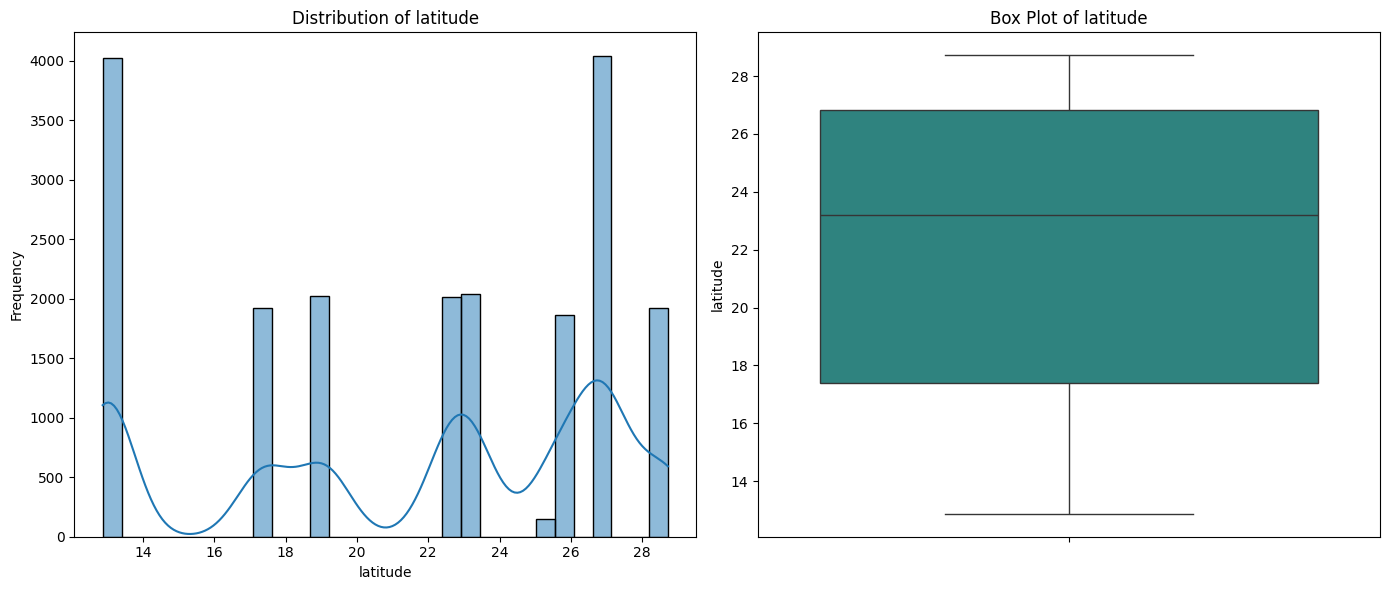

In [16]:
# Analyze 'latitude' column
print("\n--- Analyzing 'latitude' ---")

column_name = 'latitude'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode (less informative for continuous data)
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='viridis')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `latitude` column is of float64 type with no missing values. It has a high number of unique values, consistent with geographical coordinates. The statistical summary provides a clear range and central tendency. The histogram shows the distribution of incidents across different latitudes, while the box plot helps identify potential outliers, which could represent incidents in areas geographically distant from the main clusters. These geographical coordinates are crucial for spatial analysis and can be directly used by location-aware machine learning models.

# Machine Learning Importance: High
# Whether the feature should be: Keep


#### Column: `longitude`

- **Business Purpose**: Represents the geographical longitude coordinate of the incident location. Complementary to latitude, it provides the full spatial context of each incident.
- **Data Type (dtype)**: `float64`.
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct longitude values.
- **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
- **Value Counts**: Not typically useful for continuous numerical data.
- **Percentage Distribution**: Not typically useful for continuous numerical data.
- **Mode**: The most frequent longitude value (less informative for continuous data).
- **Minimum Value**: The lowest longitude recorded.
- **Maximum Value**: The highest longitude recorded.
- **Mean**: The average longitude.
- **Median**: The middle longitude value.
- **Standard Deviation**: Measure of spread for longitude values.
- **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
- **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
- **Suggested Visualization**: Histogram for distribution, box plot for outliers, scatter plot with `latitude` for geographical patterns.
- **Observation**: Similar to `latitude`, `longitude` is a continuous numerical feature essential for spatial analysis. Its distribution and range, when combined with latitude, can reveal geographical patterns, such as incident density in certain longitudes.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep


--- Analyzing 'longitude' ---
Data Type: float64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 19790

Statistical Summary:


,longitude
count,20000.000000
mean,79.419284
std,4.313909
min,72.764977
25%,77.207536
50%,77.669767
75%,80.949044
max,88.460186


Mode: 72.908076

Number of potential outliers: 2014


/tmp/ipykernel_844/4234455787.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_844/4234455787.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='viridis')


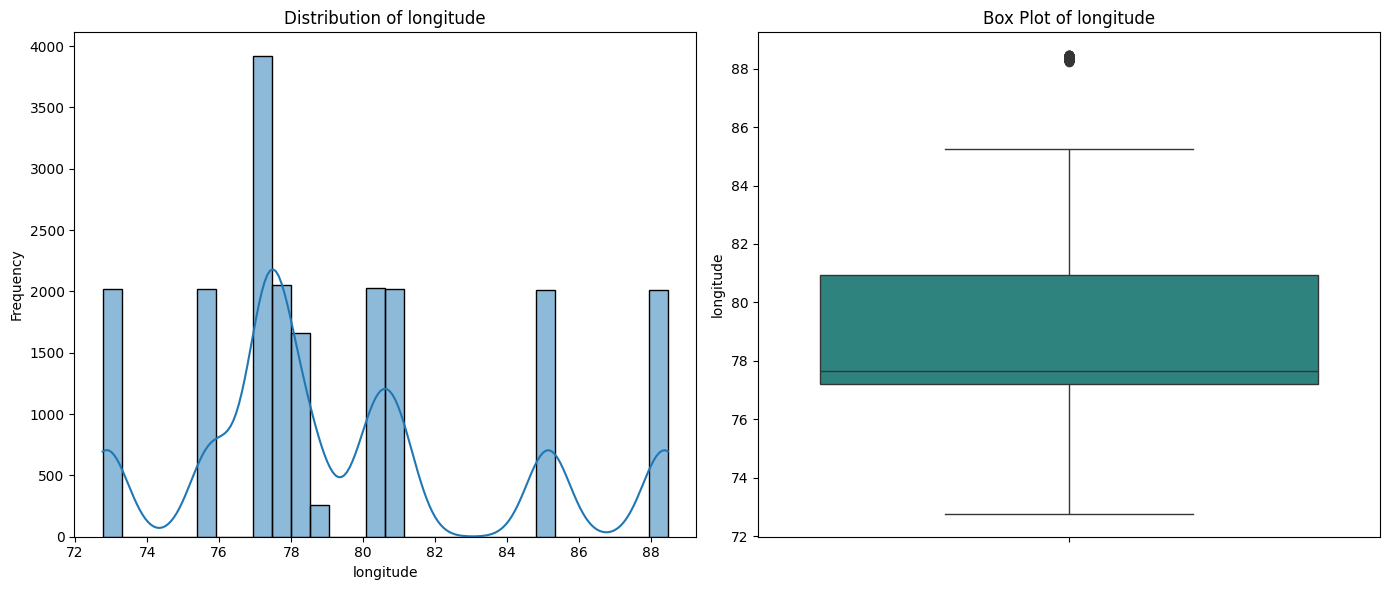

In [17]:
# Analyze 'longitude' column
print("\n--- Analyzing 'longitude' ---")

column_name = 'longitude'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode (less informative for continuous data)
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='viridis')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `longitude` column, like `latitude`, is of float64 type and contains no missing values. It exhibits a wide range of unique values, which is typical for geographical coordinates. The statistical summary provides insights into its central tendency and spread. The histogram displays the distribution, indicating how incident locations are spread across longitudes, and the box plot helps identify any potential outliers. Both latitude and longitude are fundamental for understanding the spatial context of incidents and will be crucial for any location-based predictive modeling.

# Machine Learning Importance: High
# Whether the feature should be: Keep


#### Column: `crime_type`

- **Business Purpose**: Categorizes the type of crime or incident reported. This is a crucial categorical feature that directly relates to the safety aspects of the dataset.
- **Data Type (dtype)**: `object` (string).
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct crime types.
- **Unique Categories (if categorical)**: List of all unique crime types.
- **Value Counts**: Frequency of each crime type.
- **Percentage Distribution**: Proportion of each crime type.
- **Mode**: The most frequent crime type.
- **Minimum Value**: Not applicable.
- **Maximum Value**: Not applicable.
- **Mean**: Not applicable.
- **Median**: Not applicable.
- **Standard Deviation**: Not applicable.
- **Outlier Detection (for numeric columns)**: Not applicable.
- **Suggested Visualization**: Bar chart for value counts, pie chart for distribution.
- **Observation**: This column is a key categorical feature, directly indicating the nature of the incidents. Its distribution will show which types of incidents are most prevalent. This information is vital for understanding safety concerns and is expected to be a highly important feature for predictive modeling related to safety or risk levels.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep / Transform (via one-hot encoding or target encoding for ML models)


--- Analyzing 'crime_type' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 10
Unique Categories: ['Domestic Violence' 'Assault' 'Verbal Abuse' 'Chain Snatching' 'Stalking'
 'Cyber Crime' 'Harassment' 'Kidnapping' 'Night Safety Complaint'
 'Unsafe Transport']

Value Counts:


,count
crime_type,
Night Safety Complaint,2047
Cyber Crime,2045
Harassment,2036
Stalking,2036
Verbal Abuse,2000
Assault,1999
Kidnapping,1992
Unsafe Transport,1978
Chain Snatching,1938



Percentage Distribution:


,proportion
crime_type,
Night Safety Complaint,10.235
Cyber Crime,10.225
Harassment,10.180
Stalking,10.180
Verbal Abuse,10.000
Assault,9.995
Kidnapping,9.960
Unsafe Transport,9.890
Chain Snatching,9.690


Mode: Night Safety Complaint


/tmp/ipykernel_844/707728388.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column_name, order=value_counts.index, palette='viridis')


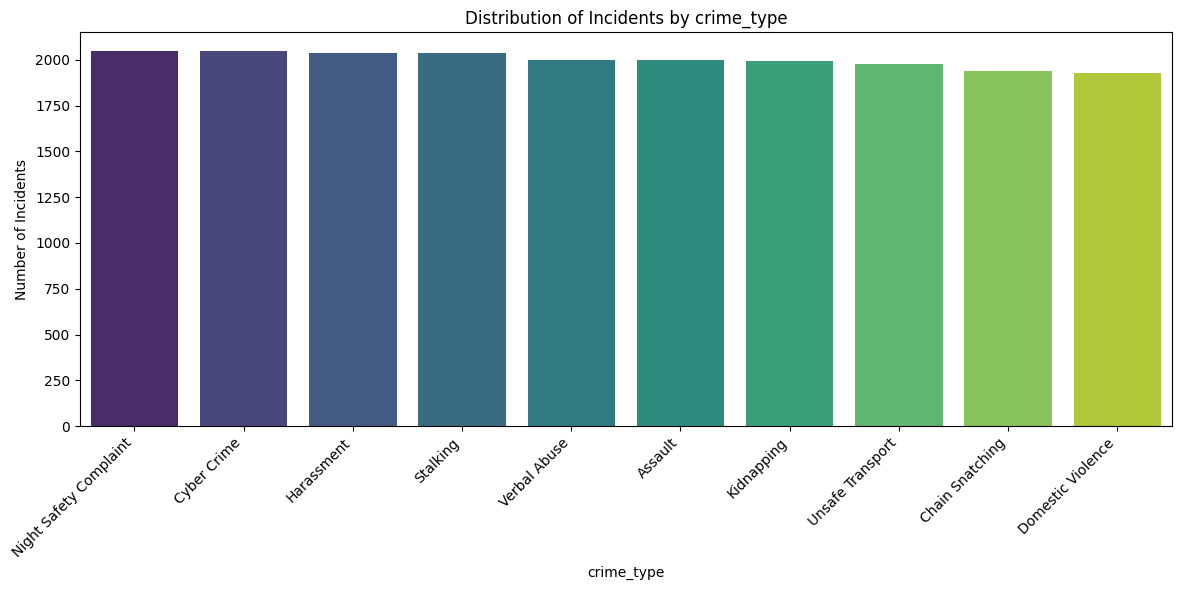

In [18]:
# Analyze 'crime_type' column
print("\n--- Analyzing 'crime_type' ---")

column_name = 'crime_type'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Unique Categories
unique_categories = df[column_name].unique()
print(f"Unique Categories: {unique_categories}")

# Value Counts
value_counts = df[column_name].value_counts()
print("\nValue Counts:")
display(value_counts)

# Percentage Distribution
percentage_distribution = df[column_name].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
display(percentage_distribution)

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Suggested Visualization: Bar Chart
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x=column_name, order=value_counts.index, palette='viridis')
plt.title(f'Distribution of Incidents by {column_name}')
plt.xlabel(column_name)
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Observation:
# The `crime_type` column is of object type, representing categorical data with 10 unique categories. There are no missing values. The value counts show that 'Night Safety Complaint' and 'Cyber Crime' are the most frequent incident types, each accounting for slightly over 10% of the total, while 'Domestic Violence' is the least frequent. The distribution across different crime types is relatively even, suggesting a diverse range of incidents recorded. This feature is highly important for understanding the nature of safety risks and will be a strong predictor for machine learning models, especially for tasks like risk assessment or classification.

# Machine Learning Importance: High
# Whether the feature should be: Keep (will require encoding for ML models, e.g., One-Hot Encoding or Target Encoding)


#### Column: `crime_count`

- **Business Purpose**: Represents the number of crimes recorded in a specific incident or location. This is a direct numerical measure of crime activity.
- **Data Type (dtype)**: `int64`.
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct crime count values.
- **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
- **Value Counts**: Frequency of each crime count (useful if range is small).
- **Percentage Distribution**: Not typically useful for continuous numerical data.
- **Mode**: The most frequent crime count value.
- **Minimum Value**: The lowest crime count recorded.
- **Maximum Value**: The highest crime count recorded.
- **Mean**: The average crime count.
- **Median**: The middle crime count value.
- **Standard Deviation**: Measure of spread for crime count values.
- **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
- **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
- **Suggested Visualization**: Histogram for distribution, box plot for outliers.
- **Observation**: As a quantitative feature, `crime_count` is a direct measure of incident severity or frequency at a given point. Its distribution can reveal common crime levels, and extreme values might indicate significant incidents or data anomalies.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep


--- Analyzing 'crime_count' ---
Data Type: int64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 85

Statistical Summary:


,crime_count
count,20000.000000
mean,32.356850
std,17.146166
min,0.000000
25%,18.000000
50%,32.000000
75%,46.000000
max,85.000000


Mode: 41

Number of potential outliers: 0


/tmp/ipykernel_844/3761953745.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_844/3761953745.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='viridis')


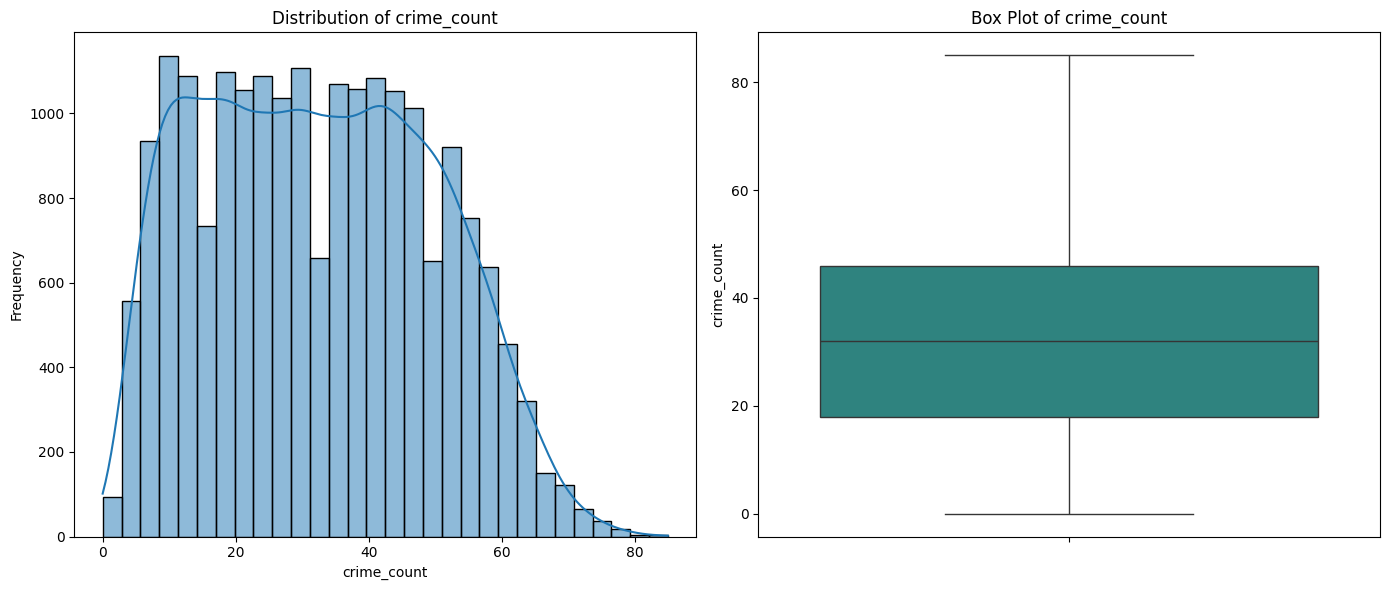

In [19]:
# Analyze 'crime_count' column
print("\n--- Analyzing 'crime_count' ---")

column_name = 'crime_count'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='viridis')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `crime_count` column is of integer type and has no missing values. It ranges from 0 to 85, with an average of approximately 32 crimes per incident. The standard deviation indicates a moderate spread of data. The histogram shows a relatively uniform distribution across the range, with no clear skewness, suggesting that various crime counts are almost equally represented. The box plot confirms this, showing a broad spread without significant outliers based on the IQR method. This feature is a direct quantitative measure and will be highly important for any predictive model aiming to understand or forecast crime activity and safety.

# Machine Learning Importance: High
# Whether the feature should be: Keep


#### Column: `time_of_day`

- **Business Purpose**: Categorizes the time of day when an incident occurred. This temporal feature can be highly indicative of patterns in crime and safety risks.
- **Data Type (dtype)**: `object` (string).
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct time categories.
- **Unique Categories (if categorical)**: List of all unique time categories.
- **Value Counts**: Frequency of each time category.
- **Percentage Distribution**: Proportion of incidents in each time category.
- **Mode**: The most frequent time of day for incidents.
- **Minimum Value**: Not applicable.
- **Maximum Value**: Not applicable.
- **Mean**: Not applicable.
- **Median**: Not applicable.
- **Standard Deviation**: Not applicable.
- **Outlier Detection (for numeric columns)**: Not applicable.
- **Suggested Visualization**: Bar chart for value counts, pie chart for distribution.
- **Observation**: This categorical column provides temporal context for incidents. The distribution across different times of day can reveal when incidents are most likely to occur, which is a critical insight for prevention and resource allocation. This feature is expected to be highly important for predictive modeling.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep / Transform (via one-hot encoding or target encoding for ML models)


--- Analyzing 'time_of_day' ---
Data Type: object
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 5
Unique Categories: ['Afternoon' 'Morning' 'Evening' 'Late Night' 'Night']

Value Counts:


,count
time_of_day,
Night,4061
Evening,4029
Morning,3987
Afternoon,3978
Late Night,3945



Percentage Distribution:


,proportion
time_of_day,
Night,20.305
Evening,20.145
Morning,19.935
Afternoon,19.890
Late Night,19.725


Mode: Night


/tmp/ipykernel_844/459313856.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=column_name, order=value_counts.index, palette='crest')


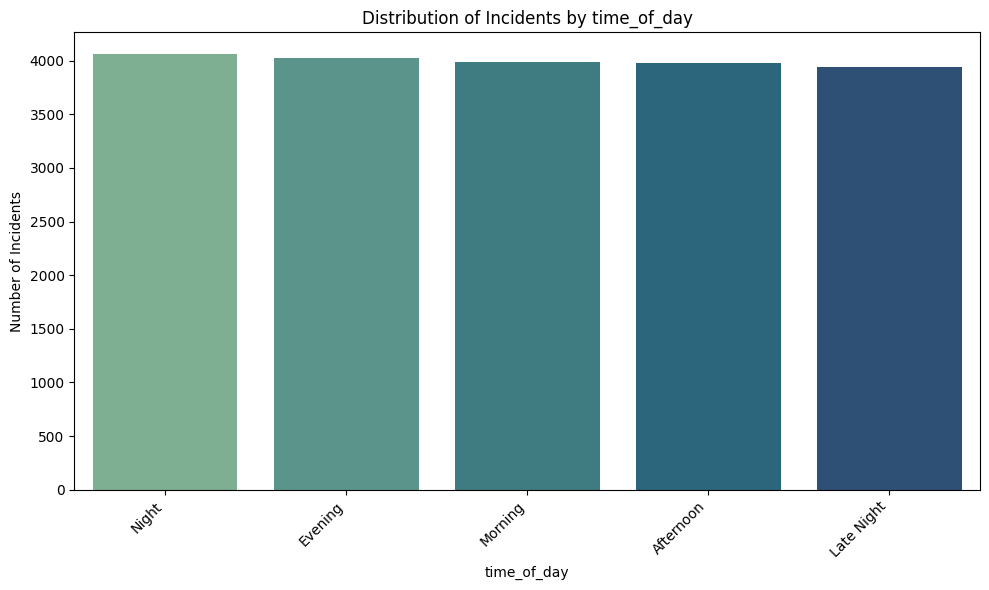

In [20]:
# Analyze 'time_of_day' column
print("\n--- Analyzing 'time_of_day' ---")

column_name = 'time_of_day'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Unique Categories
unique_categories = df[column_name].unique()
print(f"Unique Categories: {unique_categories}")

# Value Counts
value_counts = df[column_name].value_counts()
print("\nValue Counts:")
display(value_counts)

# Percentage Distribution
percentage_distribution = df[column_name].value_counts(normalize=True) * 100
print("\nPercentage Distribution:")
display(percentage_distribution)

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Suggested Visualization: Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x=column_name, order=value_counts.index, palette='crest')
plt.title(f'Distribution of Incidents by {column_name}')
plt.xlabel(column_name)
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Observation:
# The `time_of_day` column is of object type, representing categorical data with 5 unique categories. There are no missing values. The distribution across the different times of day is fairly even, with 'Night' and 'Evening' being slightly more frequent, and 'Late Night' being the least frequent. Each time category accounts for approximately 19-20% of the incidents. This feature is highly valuable for understanding temporal crime patterns and will be important for any predictive model, particularly for identifying high-risk periods.

# Machine Learning Importance: High
# Whether the feature should be: Keep (will require encoding for ML models)


#### Column: `lighting_score`

- **Business Purpose**: Represents the quality or intensity of lighting in the area of the incident. This is a crucial environmental factor that can influence visibility and perceived safety.
- **Data Type (dtype)**: `float64`.
- **Total Records**: The total number of entries in this column.
- **Non-null Count**: Number of non-missing values.
- **Missing Values**: Count of missing values.
- **Missing Percentage**: Percentage of missing values.
- **Number of Unique Values**: Count of distinct lighting score values.
- **Unique Categories (if categorical)**: Not applicable, as it's a numerical column.
- **Value Counts**: Not typically useful for continuous numerical data.
- **Percentage Distribution**: Not typically useful for continuous numerical data.
- **Mode**: The most frequent lighting score value (less informative for continuous data).
- **Minimum Value**: The lowest lighting score recorded.
- **Maximum Value**: The highest lighting score recorded.
- **Mean**: The average lighting score.
- **Median**: The middle lighting score value.
- **Standard Deviation**: Measure of spread for lighting score values.
- **Quartiles (Q1, Q2, Q3)**: Values dividing the data into quarters.
- **Outlier Detection (for numeric columns)**: Assess using box plots or IQR method.
- **Suggested Visualization**: Histogram for distribution, box plot for outliers.
- **Observation**: As a numerical feature, `lighting_score` is directly related to environmental conditions at the incident location. Its distribution can indicate common lighting conditions, and lower scores might correlate with higher risk areas. This feature is expected to have a significant impact on safety predictions.
- **Machine Learning Importance**: High
- **Whether the feature should be**: Keep


--- Analyzing 'lighting_score' ---
Data Type: float64
Total Records: 20000
Non-null Count: 20000
Missing Values: 0 (0.00%) 
Number of Unique Values: 901

Statistical Summary:


,lighting_score
count,20000.000000
mean,5.493725
std,2.592954
min,1.000000
25%,3.220000
50%,5.500000
75%,7.750000
max,10.000000


Mode: 4.46

Number of potential outliers: 0


/tmp/ipykernel_844/2475793898.py:47: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_844/2475793898.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[column_name], palette='viridis')


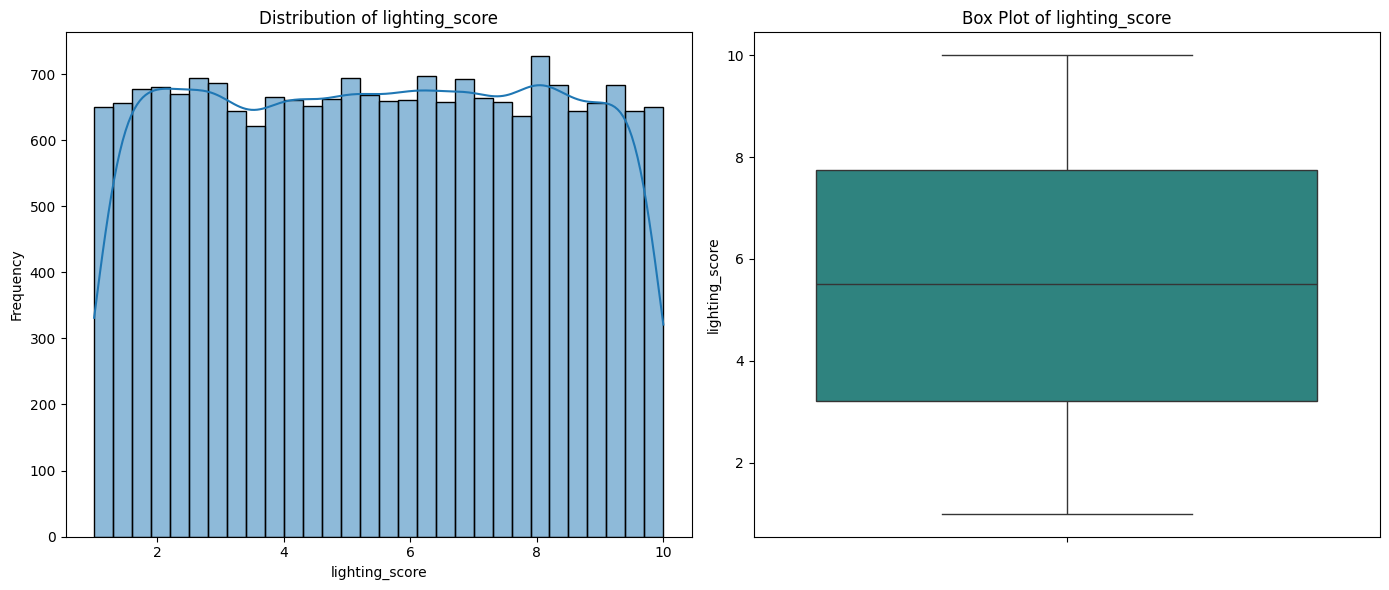

In [21]:
# Analyze 'lighting_score' column
print("\n--- Analyzing 'lighting_score' ---")

column_name = 'lighting_score'

# Data Type
print(f"Data Type: {df[column_name].dtype}")

# Total Records
total_records = len(df[column_name])
print(f"Total Records: {total_records}")

# Non-null Count
non_null_count = df[column_name].count()
print(f"Non-null Count: {non_null_count}")

# Missing Values and Percentage
missing_values = df[column_name].isnull().sum()
missing_percentage = (missing_values / total_records) * 100
print(f"Missing Values: {missing_values} ({missing_percentage:.2f}%) ")

# Number of Unique Values
unique_values_count = df[column_name].nunique()
print(f"Number of Unique Values: {unique_values_count}")

# Statistical Summary
print("\nStatistical Summary:")
display(df[column_name].describe())

# Mode
mode_value = df[column_name].mode()[0]
print(f"Mode: {mode_value}")

# Outlier Detection (using IQR method)
Q1 = df[column_name].quantile(0.25)
Q3 = df[column_name].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
print(f"\nNumber of potential outliers: {len(outliers)}")

# Suggested Visualization: Histogram and Box Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[column_name], kde=True, bins=30, palette='viridis')
plt.title(f'Distribution of {column_name}')
plt.xlabel(column_name)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[column_name], palette='viridis')
plt.title(f'Box Plot of {column_name}')
plt.ylabel(column_name)

plt.tight_layout()
plt.show()

# Observation:
# The `lighting_score` column is a float64 type with no missing values. It ranges from 1.0 to 10.0, with a mean of approximately 5.49, indicating a moderate average lighting condition. The standard deviation suggests a relatively wide spread of lighting scores. The histogram shows a fairly uniform distribution, meaning various lighting conditions are represented without strong peaks. The box plot indicates no significant outliers using the IQR method. This feature is crucial as lighting can significantly impact safety and visibility, making it a valuable input for predictive models.

# Machine Learning Importance: High
# Whether the feature should be: Keep


In [7]:
display(df.describe())

,latitude,longitude,crime_count,lighting_score,police_station_distance_km,crowd_density,safety_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,21.625279,79.419284,32.356850,5.493725,4.116744,505.148050,0.714330
std,5.430797,4.313909,17.146166,2.592954,2.233540,284.978533,0.219358
min,12.874962,72.764977,0.000000,1.000000,0.200000,10.000000,0.000000
25%,17.385593,77.207536,18.000000,3.220000,2.220000,259.000000,0.560000
50%,23.188318,77.669767,32.000000,5.500000,4.110000,502.000000,0.730000
75%,26.842789,80.949044,46.000000,7.750000,6.040000,750.000000,0.900000
max,28.718786,88.460186,85.000000,10.000000,8.000000,1000.000000,1.000000


In [8]:
df.shape

(20000, 15)

In [9]:


df.columns

Index(['incident_id', 'city', 'area', 'latitude', 'longitude', 'crime_type',
       'crime_count', 'time_of_day', 'lighting_score',
       'police_station_distance_km', 'crowd_density', 'weather_condition',
       'safety_score', 'risk_level', 'incident_timestamp'],
      dtype='object')

In [10]:
df.isnull().sum()

,0
incident_id,0
city,0
area,0
latitude,0
longitude,0
crime_type,0
crime_count,0
time_of_day,0
lighting_score,0
police_station_distance_km,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["city"].value_counts()

,count
city,
Bhopal,2043
Chennai,2026
Jaipur,2021
Mumbai,2019
Lucknow,2016
Patna,2015
Kolkata,2014
Bengaluru,2000
Delhi,1925


<Axes: xlabel='city'>

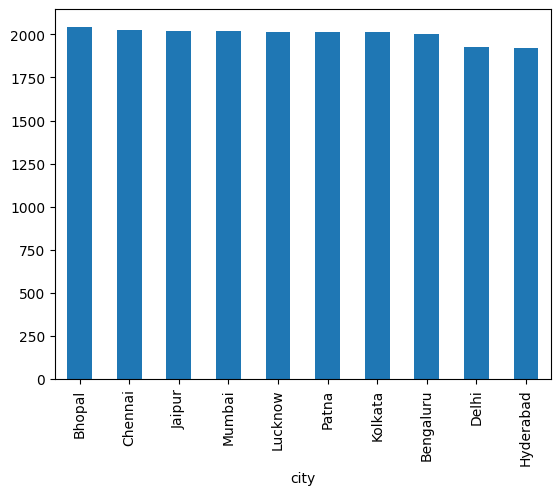

In [13]:
df["city"].value_counts().plot(kind="bar")

In [14]:
df["crime_type"].value_counts()

,count
crime_type,
Night Safety Complaint,2047
Cyber Crime,2045
Harassment,2036
Stalking,2036
Verbal Abuse,2000
Assault,1999
Kidnapping,1992
Unsafe Transport,1978
Chain Snatching,1938


In [15]:
df["risk_level"].value_counts()

,count
risk_level,
Low,9301
Medium,6940
High,3260
Critical,499


In [16]:
df["time_of_day"].value_counts()

,count
time_of_day,
Night,4061
Evening,4029
Morning,3987
Afternoon,3978
Late Night,3945


In [17]:
df["weather_condition"].value_counts()

,count
weather_condition,
Clear,4054
Stormy,4032
Rainy,4016
Humid,3971
Foggy,3927


In [18]:
df["safety_score"].mean()

np.float64(0.7143305)

In [19]:
df.groupby("area")["crime_count"].sum().sort_values(ascending=False)

,crime_count
area,
TT Nagar,14244
T Nagar,14076
Indiranagar,14021
Kukatpally,13877
Habibganj,13791
Vaishali Nagar,13778
Hazratganj,13768
Arera Colony,13757
Koramangala,13709


In [20]:
df.groupby("city")["crime_count"].sum().sort_values(ascending=False)

,crime_count
city,
Bhopal,67843
Bengaluru,65610
Chennai,65185
Jaipur,65148
Lucknow,65099
Mumbai,64740
Kolkata,64730
Patna,64227
Hyderabad,62800


In [21]:
df[["lighting_score","safety_score"]].corr()

,lighting_score,safety_score
lighting_score,1.000000,0.526788
safety_score,0.526788,1.000000


In [22]:
df.groupby("risk_level")["police_station_distance_km"].mean()

,police_station_distance_km
risk_level,
Critical,7.025431
High,5.921457
Low,2.935913
Medium,4.642408


In [23]:
df.groupby("risk_level")["crowd_density"].mean()

,crowd_density
risk_level,
Critical,509.194389
High,513.742331
Low,504.383937
Medium,501.844092


In [24]:
df["crime_count"].describe()

,crime_count
count,20000.000000
mean,32.356850
std,17.146166
min,0.000000
25%,18.000000
50%,32.000000
75%,46.000000
max,85.000000


In [25]:
df["incident_timestamp"] = pd.to_datetime(df["incident_timestamp"])

df["Month"] = df["incident_timestamp"].dt.month_name()

In [26]:
df.groupby("Month")["crime_count"].sum()

,crime_count
Month,
April,50487
August,54570
December,53695
February,49842
January,53357
July,57749
June,51002
March,55229
May,59012


In [27]:
df.corr(numeric_only=True)

,latitude,longitude,crime_count,lighting_score,police_station_distance_km,crowd_density,safety_score
latitude,1.000000,0.131835,-0.006918,0.005251,0.008204,0.009306,0.002129
longitude,0.131835,1.000000,-0.006575,0.005505,0.002534,0.002273,0.003810
crime_count,-0.006918,-0.006575,1.000000,-0.013968,-0.001181,0.005744,-0.581070
lighting_score,0.005251,0.005505,-0.013968,1.000000,-0.005239,0.006342,0.526788
police_station_distance_km,0.008204,0.002534,-0.001181,-0.005239,1.000000,0.014400,-0.599331
crowd_density,0.009306,0.002273,0.005744,0.006342,0.014400,1.000000,-0.009363
safety_score,0.002129,0.003810,-0.581070,0.526788,-0.599331,-0.009363,1.000000


<Axes: >

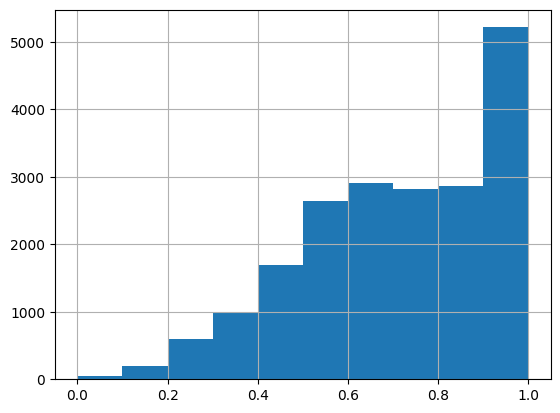

In [28]:
df["safety_score"].hist()

In [29]:
df[df["risk_level"]=="High"]

,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp,Month
4,9e5035a9-0d9b-40fc-a1e8-21702c65096e,Jaipur,Malviya Nagar,26.899559,75.765028,Chain Snatching,56,Evening,6.43,6.50,757,Humid,0.42,High,2025-02-16 06:47:57,February
10,af56eaff-1bda-4226-bcf9-044b2d0c4847,Patna,Danapur,25.590631,85.128567,Kidnapping,44,Night,4.56,7.33,479,Rainy,0.37,High,2025-05-12 17:26:28,May
11,c2847f2b-9575-4f18-86a3-5c537c0900a4,Bengaluru,Indiranagar,12.957781,77.626314,Kidnapping,47,Late Night,5.85,6.03,448,Stormy,0.50,High,2025-01-30 19:02:11,January
13,9cfcd964-84a4-4209-87af-6bfe0eab1a6b,Mumbai,Bandra,19.106930,72.905638,Assault,49,Morning,4.46,4.85,489,Stormy,0.49,High,2025-05-21 06:54:57,May
19,e59bc447-0a0f-4df6-a336-4c8edb348a69,Lucknow,Hazratganj,26.849311,80.937230,Verbal Abuse,50,Afternoon,2.16,3.91,572,Rainy,0.43,High,2024-06-16 11:27:23,June
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19966,006c2d87-c927-49b1-b805-974fe063fb53,Patna,Boring Road,25.593163,85.138275,Verbal Abuse,65,Afternoon,3.96,4.45,457,Rainy,0.36,High,2024-09-05 22:56:22,September
19975,10ed58bb-57ed-4627-bbee-946aef110a20,Mumbai,Bandra,19.023407,72.886710,Verbal Abuse,28,Late Night,1.64,6.97,431,Clear,0.38,High,2025-07-24 20:13:32,July
19980,d5c9bda2-b8c6-4149-bd1c-d31a4b77734d,Lucknow,Gomti Nagar,26.790892,80.941648,Stalking,43,Night,1.09,4.87,268,Clear,0.37,High,2025-04-07 04:14:36,April
19981,45f96a69-99f6-474b-b719-0dd38f3732dc,Bengaluru,Whitefield,12.947099,77.687188,Harassment,42,Late Night,3.80,7.95,274,Humid,0.31,High,2026-01-08 18:49:00,January


In [30]:
visakhapatnam_data = df[df['area'].str.contains('Visakhapatnam', case=False, na=False)]
display(visakhapatnam_data.head())

,incident_id,city,area,latitude,longitude,crime_type,crime_count,time_of_day,lighting_score,police_station_distance_km,crowd_density,weather_condition,safety_score,risk_level,incident_timestamp,Month


In [31]:
df.dtypes

,0
incident_id,object
city,object
area,object
latitude,float64
longitude,float64
crime_type,object
crime_count,int64
time_of_day,object
lighting_score,float64
police_station_distance_km,float64


In [36]:
df['crime_type'].nunique()

10

In [35]:
df['crime_type'].unique()

array(['Domestic Violence', 'Assault', 'Verbal Abuse', 'Chain Snatching',
       'Stalking', 'Cyber Crime', 'Harassment', 'Kidnapping',
       'Night Safety Complaint', 'Unsafe Transport'], dtype=object)

In [39]:
df['crime_type'].value_counts()

,count
crime_type,
Night Safety Complaint,2047
Cyber Crime,2045
Harassment,2036
Stalking,2036
Verbal Abuse,2000
Assault,1999
Kidnapping,1992
Unsafe Transport,1978
Chain Snatching,1938


In [41]:
df['incident_id'].nunique()

20000

In [42]:
df['incident_id'].unique()


array(['2b63f176-a5c9-4ac5-adbb-b81c14754ec4',
       'ef4ba791-e5b5-4146-a3bb-c63e5d695e7c',
       '6db79d9c-62d4-4c74-a2f2-295297dbc083', ...,
       '5ab3e4e3-77a6-49cc-924a-898e31eb7676',
       'bd8ad7fb-2488-40ab-8c1b-eafab004f685',
       '648e2297-f438-4f95-b1f7-4a1c4a504d59'], dtype=object)

In [43]:
df['incident_id'].dtypes


dtype('O')

In [46]:
df['city'].dtypes

dtype('O')

In [48]:
df['city'].value_counts()

,count
city,
Bhopal,2043
Chennai,2026
Jaipur,2021
Mumbai,2019
Lucknow,2016
Patna,2015
Kolkata,2014
Bengaluru,2000
Delhi,1925


In [49]:
df['safety_score'].value_counts()

,count
safety_score,
1.00,2972
0.76,329
0.68,327
0.74,326
0.71,322
...,...
0.06,6
0.01,5
0.00,4
